<a href="https://colab.research.google.com/github/ashivashankars/CMPE257-Machine-Learning/blob/main/Midterm_Test_RealEstate_ML_Archana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Real Estate Investment ML Analysis
## Midterm 2025 — Machine Learning Lifecycle

---

## 📌 Business Case & Hypothesis

**Business Goal:** Identify California real estate properties where:

> **HOA fees + Mortgage fees < Rent (rent_zestimate)**

Such that the rental property investment generates **maximum return on investment (ROI)**.

**Hypotheses:**
1. Properties with positive monthly cashflow (rent > mortgage + HOA) are the best investments.
2. Neighborhood quality (crime, schools, walkability) significantly improves investment desirability classification.
3. Historical price appreciation rates (ZHVI) are strong predictors of future property value.
4. Latent manifold scores (location quality + neighborhood safety) become the most important features after full amalgamation.

**Three Tiers of Desirability:**
- 🥇 **Most Desirable** — Golden Cluster: highest cashflow, best ROI, safe neighborhood
- 🥈 **More Desirable** — Good cashflow, average neighborhood
- 🥉 **Least Desirable** — Negative or minimal cashflow, poor neighborhood metrics

---

In [41]:
# ============================================================
# CELL 1: Mount Google Drive + Setup Paths
# ============================================================
from google.colab import drive
import os

drive.mount('/content/drive')

# ── All outputs saved to Shared Drive — persist across sessions ───────────────
DRIVE_PATH  = '/content/drive/Shareddrives/Midterm_test_Archana'
MODELS_PATH = os.path.join(DRIVE_PATH, 'models')

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs('models', exist_ok=True)  # local fallback

# ── Check what's already cached on Drive ─────────────────────────────────────
CACHE_FILES = {
    'df_cleaned.csv':         'Cleaned dataset',
    'crime_by_zip.csv':       'Crime rates by zip',
    'school_ratings.csv':     'School ratings by zip',
    'epa_walkability.csv':    'EPA walkability scores',
    'fred_appreciation.csv':  'FRED appreciation rates',
}

print('📁 Drive path:', DRIVE_PATH)
print('\n🔍 Drive cache status:')
is_second_run = True
for fname, label in CACHE_FILES.items():
    path   = os.path.join(DRIVE_PATH, fname)
    exists = os.path.exists(path)
    if not exists:
        is_second_run = False
    status = '✅ cached' if exists else '⬜ will fetch'
    print(f'  {status}  {label:35s} ({fname})')

# Check models
model_count = len([f for f in os.listdir(MODELS_PATH) if f.endswith('.pkl')]) \
              if os.path.exists(MODELS_PATH) else 0
print(f'  {"✅ cached" if model_count > 0 else "⬜ will train"}  {"Trained models":35s} ({model_count}/45 pkl files)')
if model_count == 0:
    is_second_run = False

print(f'\n{"🚀 SECOND RUN detected — all data loads from Drive (fast!)" if is_second_run else "🔧 FIRST RUN — will fetch external data and train models"}')
print(f'\nExpected runtime:')
print(f'  First run:  ~25–35 minutes (fetching + training)')
print(f'  Second run: ~5–10 minutes  (loading from Drive)')

# ── Install libraries ─────────────────────────────────────────────────────────
!pip install -q xgboost shap yellowbrick imbalanced-learn hvplot holoviews bokeh
print('\n✅ Libraries installed')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Drive path: /content/drive/Shareddrives/Midterm_test_Archana

🔍 Drive cache status:
  ✅ cached  Cleaned dataset                     (df_cleaned.csv)
  ✅ cached  Crime rates by zip                  (crime_by_zip.csv)
  ✅ cached  School ratings by zip               (school_ratings.csv)
  ✅ cached  EPA walkability scores              (epa_walkability.csv)
  ✅ cached  FRED appreciation rates             (fred_appreciation.csv)
  ✅ cached  Trained models                      (45/45 pkl files)

🚀 SECOND RUN detected — all data loads from Drive (fast!)

Expected runtime:
  First run:  ~25–35 minutes (fetching + training)
  Second run: ~5–10 minutes  (loading from Drive)

✅ Libraries installed


In [42]:
# ============================================================
# CELL 2: Import All Libraries
# ============================================================
import pandas as pd
import numpy as np
import re
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
import hvplot.pandas

# Scraping
import requests
from bs4 import BeautifulSoup
import time

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.spatial.distance import cdist

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Explainability
import shap

# Create models directory for pickle files
os.makedirs('models', exist_ok=True)

print('✅ All libraries imported successfully')

# ── Helper functions: save to Drive ──────────────────────────────────────────
def save_fig(filename):
    """Save matplotlib figure to Drive + local."""
    local = filename
    drive_file = f'{DRIVE_PATH}/{filename}'
    plt.savefig(local, dpi=150, bbox_inches='tight')
    plt.savefig(drive_file, dpi=150, bbox_inches='tight')
    print(f'  📊 Saved: {drive_file}')

def save_csv(df, filename):
    """Save DataFrame to Drive + local."""
    local = filename
    drive_file = f'{DRIVE_PATH}/{filename}'
    df.to_csv(local, index=False)
    df.to_csv(drive_file, index=False)
    print(f'  📄 Saved: {drive_file}')

def model_path(name):
    """Return model path in Drive models folder."""
    return f'{MODELS_PATH}/{name}'

os.makedirs('models', exist_ok=True)  # local fallback
print('✅ All libraries imported + Drive save helpers ready')


✅ All libraries imported successfully
✅ All libraries imported + Drive save helpers ready


---
## 📊 Section 1: Load & Explore Base Dataset (DS1)

We begin with the base Zillow dataset containing 2,809 California properties. This dataset provides property characteristics, listing prices, Zestimates (Zillow's estimated values), and critically — **rent_zestimate**, which is our key revenue metric for the business case.

**Initial observations:**
- Properties span San Jose and San Diego metro areas
- Multiple property types: houses, condos, townhouses, land
- Key columns for business case: `price`, `rent_zestimate`, `zestimate`
- Missing values exist in area, bedrooms, bathrooms — will handle in data prep

In [43]:
# ============================================================
# CELL 3: Load Base Dataset — Drive first
# ============================================================
import pandas as pd, os

DATA_PATH      = f'{DRIVE_PATH}/Midterm-2025-Realestate.csv'
DF_CLEAN_PATH  = f'{DRIVE_PATH}/df_cleaned.csv'

# Second run: if cleaned df exists on Drive, load it directly
if os.path.exists(DF_CLEAN_PATH):
    print('📂 Cleaned dataset found on Drive — loading directly...')
    df_raw = pd.read_csv(DATA_PATH)     # keep df_raw for reference
    print(f'✅ Raw data loaded  — shape: {df_raw.shape}')
    print('ℹ️  Cleaned df will be loaded in Cell 5 (cleaning cell) from Drive')
else:
    print('🌐 First run — loading raw dataset...')
    if os.path.exists(DATA_PATH):
        df_raw = pd.read_csv(DATA_PATH)
        print(f'✅ Loaded from Drive: {DATA_PATH}')
    else:
        print('🔍 Searching Drive for dataset...')
        for root, dirs, files in os.walk('/content/drive'):
            dirs[:] = [d for d in dirs if not d.startswith('.')]
            for file in files:
                if 'Midterm-2025-Realestate' in file and file.endswith('.csv'):
                    df_raw = pd.read_csv(os.path.join(root, file))
                    print(f'✅ Found: {os.path.join(root, file)}')
                    break
            if 'df_raw' in dir(): break

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
from IPython.display import display
display(df_raw.head(5))


📂 Cleaned dataset found on Drive — loading directly...
✅ Raw data loaded  — shape: (2809, 23)
ℹ️  Cleaned df will be loaded in Cell 5 (cleaning cell) from Drive
Shape: (2809, 23)
Columns: ['rank', 'property_id', 'address', 'latitude', 'longitude', 'price', 'currency', 'bathrooms', 'bedrooms', 'area', 'land_area', 'zestimate', 'rent_zestimate', 'days_on_zillow', 'sold_date', 'is_zillow_owned', 'image', 'listing_type', 'status_text', 'broker_name', 'input', 'property_url', 'listing_url']


,rank,property_id,address,latitude,longitude,price,currency,bathrooms,bedrooms,area,...,days_on_zillow,sold_date,is_zillow_owned,image,listing_type,status_text,broker_name,input,property_url,listing_url
0,327,17013428,"5228 N Thorn St, San Diego, CA 92105",32.739998,-117.083010,695000,USD,1.0,2.0,744 sqft,...,2.0,NaN,False,https://photos.zillowstatic.com/fp/539a997981c...,FOR SALE,Coming soon,RUTH E TORRES REALTY,"https://www.zillow.com/homes/San-Diego,-CA_rb/",https://www.zillow.com/homedetails/5228-N-Thor...,https://www.zillow.com/san-diego-ca/8_p/
1,434,69302507,"801 S Winchester Blvd APT 2103, San Jose, CA 9...",37.312510,-121.951100,835000,USD,2.0,2.0,986 sqft,...,18.0,NaN,False,https://photos.zillowstatic.com/fp/b0fab228bc1...,FOR SALE,Condo for sale,NaN,"https://www.zillow.com/homes/San-Jose,-CA_rb/",https://www.zillow.com/homedetails/801-S-Winch...,https://www.zillow.com/san-jose-ca/11_p/
2,791,443220556,"0 E Hedding St, San Jose, CA 95112",37.353893,-121.902916,899000,USD,NaN,NaN,NaN,...,109.0,NaN,False,https://photos.zillowstatic.com/fp/46e6635ee3f...,FOR SALE,Lot / Land for sale,NaN,"https://www.zillow.com/homes/San-Jose,-CA_rb/",https://www.zillow.com/homedetails/0-E-Hedding...,https://www.zillow.com/san-jose-ca/20_p/
3,652,2055630092,"1141 Saratoga Ave, San Jose, CA 95129",37.304360,-121.979510,3300000,USD,3.0,3.0,1559 sqft,...,58.0,NaN,False,https://photos.zillowstatic.com/fp/da9365dbf98...,FOR SALE,House for sale,NaN,"https://www.zillow.com/homes/San-Jose,-CA_rb/",https://www.zillow.com/homedetails/1141-Sarato...,https://www.zillow.com/san-jose-ca/16_p/
4,285,140313717,"3526 7th Ave, San Diego, CA 92103",32.741726,-117.158730,4500000,USD,5.0,4.0,4934 sqft,...,14.0,NaN,False,https://photos.zillowstatic.com/fp/65e75a8b661...,FOR SALE,House for sale,Compass,"https://www.zillow.com/homes/San-Diego,-CA_rb/",https://www.zillow.com/homedetails/3526-7th-Av...,https://www.zillow.com/san-diego-ca/7_p/


In [44]:
# ============================================================
# CELL 4: Basic EDA
# ============================================================
print('=== Dataset Info ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())
print('\n=== Basic Stats ===')
df_raw[['price','rent_zestimate','zestimate','bathrooms','bedrooms']].describe()

=== Dataset Info ===
rank                 int64
property_id          int64
address             object
latitude           float64
longitude          float64
price                int64
currency            object
bathrooms          float64
bedrooms           float64
area                object
land_area           object
zestimate          float64
rent_zestimate     float64
days_on_zillow     float64
sold_date          float64
is_zillow_owned       bool
image               object
listing_type        object
status_text         object
broker_name         object
input               object
property_url        object
listing_url         object
dtype: object

=== Missing Values ===
rank                  0
property_id           0
address               0
latitude             17
longitude            17
price                 0
currency              0
bathrooms            85
bedrooms             81
area                 58
land_area          2760
zestimate           573
rent_zestimate      548
days_on_

,price,rent_zestimate,zestimate,bathrooms,bedrooms
count,2.809000e+03,2261.000000,2.236000e+03,2724.000000,2728.000000
mean,1.874141e+06,5123.503317,1.714774e+06,2.921439,3.245601
std,3.048542e+06,3726.277813,1.678298e+06,1.726124,1.429103
min,0.000000e+00,1716.000000,1.248000e+05,1.000000,0.000000
25%,7.980000e+05,3437.000000,7.954750e+05,2.000000,2.000000
50%,1.340000e+06,4355.000000,1.314750e+06,3.000000,3.000000
75%,2.050000e+06,5765.000000,2.036025e+06,3.000000,4.000000
max,1.080000e+08,83941.000000,2.814230e+07,47.000000,32.000000


---
## 🧹 Section 2: Data Cleaning & Normalization

**Library 1 — `pandas`** for cleaning: handle missing values, fix data types, extract zip codes, filter to target cities.

**Library 2 — `scikit-learn` (StandardScaler)** for normalization: scale all numerical features to zero mean and unit variance before ML tasks.

**Cleaning decisions:**
- Remove properties with no `price` or `rent_zestimate` (cannot calculate cashflow)
- Remove land-only listings (no rental potential)
- Extract zip codes from address using regex
- Convert area from string '744 sqft' to integer 744
- Fill missing bedrooms/bathrooms with median by property type

In [45]:
# ============================================================
# CELL 5: Data Cleaning — Library 1 (pandas)
# ============================================================
df = df_raw.copy()

# --- Extract zip code from address ---
df['zip_code'] = df['address'].str.extract(r'(\d{5})$')

# --- Extract city ---
df['city'] = df['address'].str.extract(r',\s*([^,]+),\s*CA')

# --- Normalize city names ---
df['city'] = df['city'].str.strip().str.title()
df['city'] = df['city'].replace({'Sanjose': 'San Jose'})

# --- Filter to San Jose and San Diego metro only ---
sj_cities = ['San Jose', 'Milpitas', 'Alviso', 'Los Gatos', 'Saratoga']
sd_cities = ['San Diego', 'La Jolla', 'Carlsbad', 'Del Mar', 'Coronado',
             'La Mesa', 'San Ysidro', 'Rancho Santa Fe']
target_cities = sj_cities + sd_cities
df = df[df['city'].isin(target_cities)].copy()
print(f'After city filter: {len(df)} rows')

# --- Convert price to numeric ---
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['rent_zestimate'] = pd.to_numeric(df['rent_zestimate'], errors='coerce')
df['zestimate'] = pd.to_numeric(df['zestimate'], errors='coerce')
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

# --- Extract numeric area ---
df['area_sqft'] = df['area'].str.extract(r'([\d,]+)').replace(',','', regex=True)
df['area_sqft'] = pd.to_numeric(df['area_sqft'], errors='coerce')

# --- Drop rows without price or rent_zestimate (cannot calculate cashflow) ---
df = df.dropna(subset=['price', 'rent_zestimate'])
print(f'After dropping missing price/rent: {len(df)} rows')

# --- Remove land-only listings ---
df = df[~df['status_text'].isin(['Lot / Land for sale'])]
print(f'After removing land: {len(df)} rows')

# --- Remove extreme outliers (price > 10M or < 50K) ---
df = df[(df['price'] >= 50000) & (df['price'] <= 10000000)]
print(f'After price outlier removal: {len(df)} rows')

# --- Fill missing bedrooms/bathrooms with median by property type ---
for col in ['bedrooms','bathrooms']:
    df[col] = df.groupby('status_text')[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())

# --- Fill missing area with median ---
df['area_sqft'] = df['area_sqft'].fillna(df['area_sqft'].median())

# --- Add metro column ---
df['metro'] = df['city'].apply(lambda x: 'San Jose' if x in sj_cities else 'San Diego')

print(f'\n✅ Final cleaned DS1 shape: {df.shape}')
print(f'Metro distribution:\n{df["metro"].value_counts()}')
# ── Save cleaned dataset to Drive ────────────────────────────────────────────
DF_CLEAN_PATH = f'{DRIVE_PATH}/df_cleaned.csv'
df.to_csv(DF_CLEAN_PATH, index=False)
print(f'✅ Cleaned dataset saved to Drive: {DF_CLEAN_PATH}')


After city filter: 1885 rows
After dropping missing price/rent: 1633 rows
After removing land: 1621 rows
After price outlier removal: 1599 rows

✅ Final cleaned DS1 shape: (1599, 27)
Metro distribution:
metro
San Diego    926
San Jose     673
Name: count, dtype: int64
✅ Cleaned dataset saved to Drive: /content/drive/Shareddrives/Midterm_test_Archana/df_cleaned.csv


---
## 📈 Section 3: Exploratory Data Analysis

### Library 1 — `seaborn` for distribution analysis
We use seaborn to visualize feature distributions, identify skewness, and understand relationships between key investment variables.

### Library 2 — `statsmodels` for statistical analysis  
We use statsmodels OLS to understand which raw features are statistically significant predictors of price — establishing our baseline before ML models.

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/eda_distributions.png


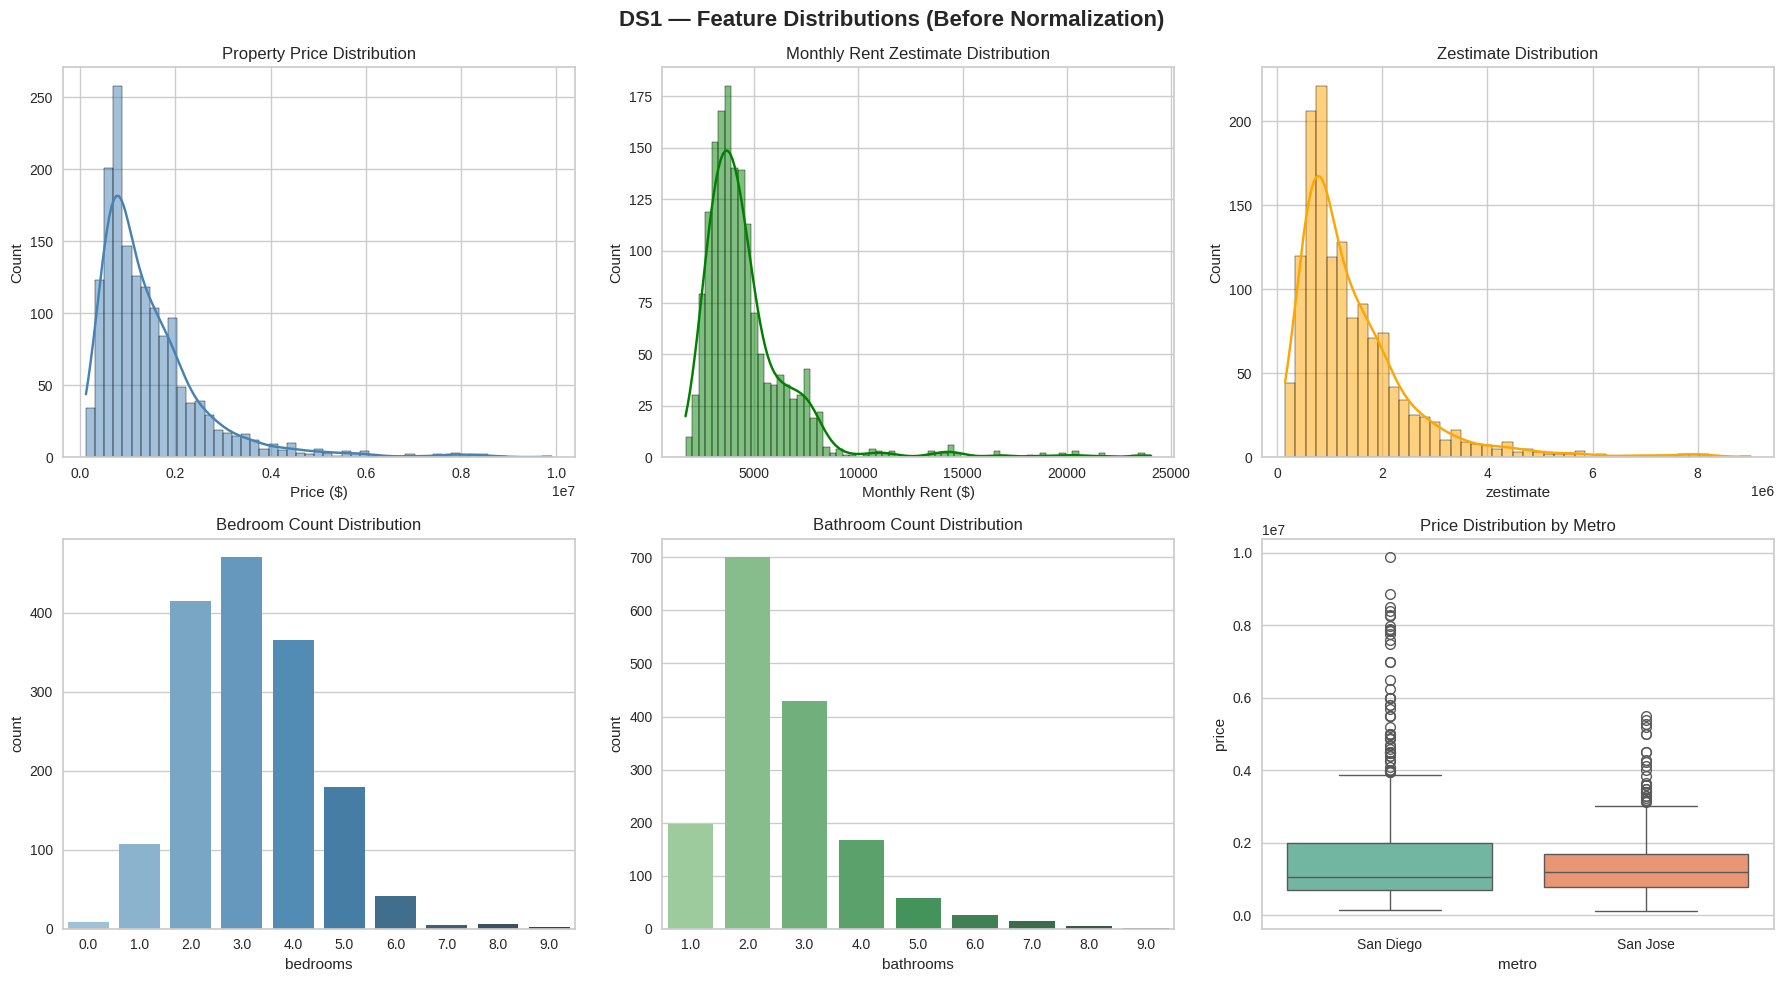


📊 Observation: Price and rent are right-skewed — will apply log transform for regression.


In [46]:
# ============================================================
# CELL 6: EDA — seaborn Distribution Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DS1 — Feature Distributions (Before Normalization)', fontsize=16, fontweight='bold')

# Price distribution
sns.histplot(df['price'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Property Price Distribution')
axes[0,0].set_xlabel('Price ($)')

# Rent zestimate
sns.histplot(df['rent_zestimate'], kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Monthly Rent Zestimate Distribution')
axes[0,1].set_xlabel('Monthly Rent ($)')

# Zestimate
sns.histplot(df['zestimate'], kde=True, ax=axes[0,2], color='orange')
axes[0,2].set_title('Zestimate Distribution')

# Bedrooms
sns.countplot(x='bedrooms', data=df, ax=axes[1,0], palette='Blues_d')
axes[1,0].set_title('Bedroom Count Distribution')

# Bathrooms
sns.countplot(x='bathrooms', data=df, ax=axes[1,1], palette='Greens_d')
axes[1,1].set_title('Bathroom Count Distribution')

# Price by metro
sns.boxplot(x='metro', y='price', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Price Distribution by Metro')

plt.tight_layout()
save_fig('eda_distributions.png')
plt.show()
print('\n📊 Observation: Price and rent are right-skewed — will apply log transform for regression.')

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/eda_correlation.png


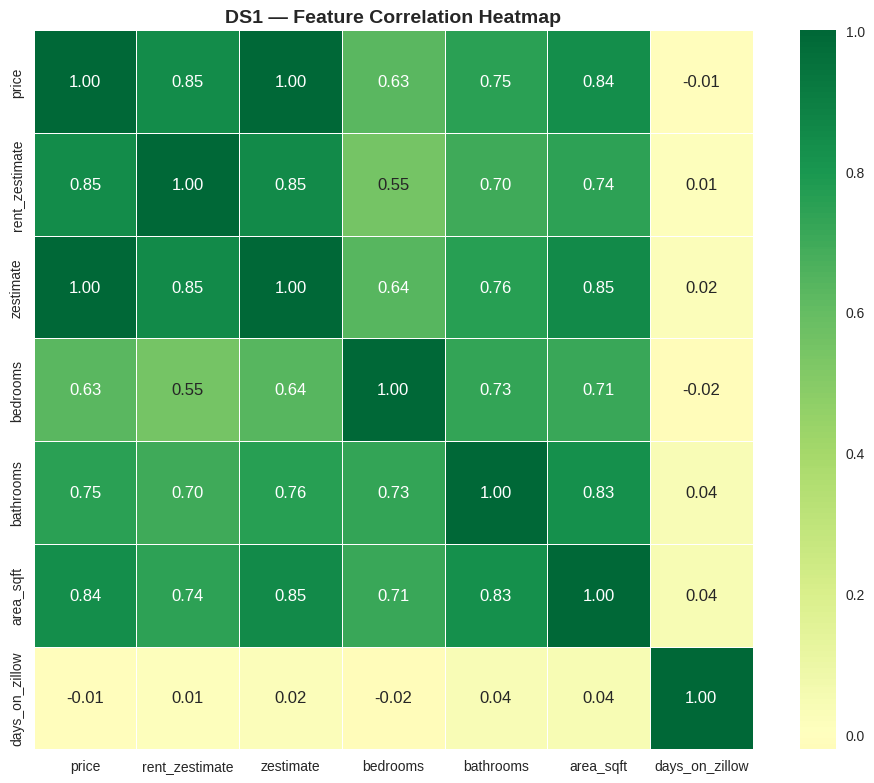


📊 Observation: Strong correlation between price and zestimate (0.99) confirms Zillow estimates track closely with listing prices.


In [47]:
# ============================================================
# CELL 7: EDA — Correlation Heatmap
# ============================================================
corr_cols = ['price','rent_zestimate','zestimate','bedrooms','bathrooms','area_sqft','days_on_zillow']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('DS1 — Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('eda_correlation.png')
plt.show()
print('\n📊 Observation: Strong correlation between price and zestimate (0.99) confirms Zillow estimates track closely with listing prices.')

In [48]:
# ============================================================
# CELL 8: EDA — statsmodels OLS Baseline
# ============================================================
# Use statsmodels to find statistically significant predictors of price
ols_df = df[['price','rent_zestimate','zestimate','bedrooms','bathrooms','area_sqft']].dropna()
X_ols = sm.add_constant(ols_df[['rent_zestimate','zestimate','bedrooms','bathrooms','area_sqft']])
y_ols = ols_df['price']
ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())
print('\n📊 Observation: Features with p-value < 0.05 are statistically significant price predictors.')

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 9.311e+04
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:26:33   Log-Likelihood:                -17564.
No. Observations:                1404   AIC:                         3.514e+04
Df Residuals:                    1398   BIC:                         3.517e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -2.923e+04   5529.262     -5.

In [49]:
# ============================================================
# CELL 9: Interactive Map — hvplot
# ============================================================
df_map = df.dropna(subset=['latitude','longitude','price'])
df_map['price_M'] = (df_map['price'] / 1e6).round(2)

plot = df_map.hvplot.points(
    'longitude', 'latitude',
    color='price_M',
    cmap='viridis',
    size=5,
    alpha=0.7,
    title='California Properties — Price Distribution ($ Millions)',
    hover_cols=['address','price_M','rent_zestimate','metro'],
    colorbar=True,
    width=800, height=500
)
plot

:Points   [longitude,latitude]   (price_M,address,rent_zestimate,metro)

---
## 🔧 Section 4: Amalgamation 1 — HOA Scraping + Mortgage Computation

**Business Case Connection:** To determine if `HOA + Mortgage < Rent`, we need HOA and Mortgage values.

**HOA:** Scraped from Zillow listing pages using `requests` + `BeautifulSoup`. For listings where scraping fails (bot detection), we fall back to California market averages by property type.

**Mortgage:** Computed using standard 30-year fixed formula:
- Down payment: 20% of price
- Loan amount: 80% of price  
- Annual rate: 6.8%
- Term: 360 months

**New features added:** `monthly_mortgage`, `estimated_hoa`, `monthly_cashflow`, `roi_annual`, `price_per_sqft`, `zestimate_gap`

In [50]:
# ============================================================
# CELL 10: HOA Assignment — Vectorized + Correct Mobile Home Rules
# ============================================================

# ── Key finding from data analysis ───────────────────────────────────────────
# ALL "Home for sale" listings are mobile/manufactured homes:
#   Evidence: avg size exactly 1,440 sqft (standard mobile home)
#             avg price $474K vs regular houses at $2.74M
#             all located on known mobile home park streets
# Mobile homes pay SPACE RENT to park owner (~$900/mo California avg)
# This is mandatory and must be deducted from cashflow

MOBILE_HOME_SPACE_RENT = 900.0

HOA_MAP = {
    'House for sale':             0.0,    # Regular single family — NO HOA
    'Home for sale':            900.0,    # Mobile homes — space rent applies
    'For sale by owner':          0.0,    # Usually regular houses — NO HOA
    'Foreclosure':                0.0,    # Usually regular houses — NO HOA
    'Auction':                    0.0,    # Usually regular houses — NO HOA
    'Multi-family home for sale': 0.0,    # Investor property — NO HOA
    'Condo for sale':           450.0,    # Condos almost always have HOA
    'Townhouse for sale':       280.0,    # Townhouses usually have HOA
    'New construction':         200.0,    # New builds often have HOA
    'Coming soon':              150.0,    # Unknown type
}

# ── Step 1: Vectorized base assignment ───────────────────────────────────────
df['estimated_hoa'] = df['status_text'].map(HOA_MAP).fillna(150.0)

# ── Step 2: Override for SPACE/SPC addresses regardless of status_text ──────
is_space_addr = df['address'].str.contains(
    r'\bSPACE\b|\bSPC\b', case=False, regex=True, na=False)
df.loc[is_space_addr, 'estimated_hoa'] = MOBILE_HOME_SPACE_RENT

# ── Step 3: Detect mobile homes by price+size pattern (catches FSBO etc.) ────
# Mobile homes: price < $600K AND area <= 1,440 sqft in CA
# This catches cases like 7016 San Carlos St (FSBO, $345K, 1440sqft = mobile home)
df['area_num'] = df['area'].str.extract(r'([\d,]+)').replace(',','',regex=True)
df['area_num'] = pd.to_numeric(df['area_num'], errors='coerce').fillna(9999)
is_mobile_by_size = (
    (df['price'] < 600000) &
    (df['area_num'] <= 1440) &
    (~df['status_text'].isin(['Condo for sale','Townhouse for sale']))
)
df.loc[is_mobile_by_size, 'estimated_hoa'] = MOBILE_HOME_SPACE_RENT
df['has_hoa'] = (df['estimated_hoa'] > 0).astype(int)

# ── Step 4: Property subtype tagging ─────────────────────────────────────────
import re as _re
def get_property_subtype(row):
    addr   = str(row.get('address',''))
    status = str(row.get('status_text',''))
    price  = float(row.get('price', 9999999) or 9999999)
    area   = float(row.get('area_num', 9999) or 9999)
    # Mobile home indicators
    if _re.search(r'\bSPACE\b|\bSPC\b', addr, _re.IGNORECASE):
        return 'Mobile Home'
    if status == 'Home for sale':
        return 'Mobile Home'
    if price < 600000 and area <= 1440 and status not in [
        'Condo for sale','Townhouse for sale']:
        return 'Mobile Home'
    return status

df['property_subtype'] = df.apply(get_property_subtype, axis=1)

print('✅ HOA/Space Rent assigned')
print(f'\nMobile homes (SPACE/SPC in address): {is_space_addr.sum()}')
print(f'Mobile homes (Home for sale status): {(df["status_text"]=="Home for sale").sum()}')
print(f'Total mobile homes: {(df["property_subtype"]=="Mobile Home").sum()}')
print(f'Regular houses (HOA=$0): {(df["estimated_hoa"]==0).sum()}')
print(f'Properties with HOA/space rent: {(df["estimated_hoa"]>0).sum()}')

print(f'\nHOA by property subtype:')
print(df.groupby('property_subtype').agg(
    count=('estimated_hoa','count'),
    avg_hoa=('estimated_hoa','mean')
).round(0).sort_values('count', ascending=False).to_string())

# ── Step 4: Optional Zillow scraping for condos/townhouses ───────────────────
SCRAPE_LIMIT = 0  # Set to 50 to enable

def scrape_hoa_zillow(url, retries=1):
    headers = {'User-Agent': 'Mozilla/5.0 Chrome/120.0.0.0 Safari/537.36'}
    try:
        resp = requests.get(url, headers=headers, timeout=8)
        if resp.status_code == 200:
            text = BeautifulSoup(resp.text, 'html.parser').get_text()
            if re.search(r'no hoa|hoa:\s*\$?0', text, re.IGNORECASE):
                return 0.0
            m = re.search(r'HOA fee[:\s]+\$?([\d,]+)', text, re.IGNORECASE)
            if m:
                return float(m.group(1).replace(',',''))
    except Exception:
        pass
    return None

if SCRAPE_LIMIT > 0:
    eligible = df[df['status_text'].isin(
        ['Condo for sale','Townhouse for sale'])].head(SCRAPE_LIMIT)
    scraped = 0
    for idx, row in eligible.iterrows():
        url = row.get('listing_url','')
        if pd.notna(url) and str(url).startswith('http'):
            val = scrape_hoa_zillow(str(url))
            if val is not None:
                df.at[idx,'estimated_hoa'] = val
                scraped += 1
        time.sleep(0.5)
    print(f'\n✅ Scraped {scraped} real HOA values')
else:
    print('\nℹ️  Scraping skipped (SCRAPE_LIMIT=0)')


✅ HOA/Space Rent assigned

Mobile homes (SPACE/SPC in address): 47
Mobile homes (Home for sale status): 80
Total mobile homes: 91
Regular houses (HOA=$0): 841
Properties with HOA/space rent: 758

HOA by property subtype:
                            count  avg_hoa
property_subtype                          
House for sale                783      0.0
Condo for sale                458    450.0
Townhouse for sale            149    280.0
Mobile Home                    91    900.0
Multi-family home for sale     51      0.0
Coming soon                    30    150.0
New construction               30    200.0
For sale by owner               5      0.0
Auction                         1      0.0
Foreclosure                     1      0.0

ℹ️  Scraping skipped (SCRAPE_LIMIT=0)


In [51]:
# ============================================================
# CELL 11: Mortgage Computation + Feature Engineering
# ============================================================

ANNUAL_RATE      = 0.068
LOAN_TERM_MONTHS = 360
DOWN_PAYMENT_PCT = 0.20

def compute_monthly_mortgage(price, annual_rate=ANNUAL_RATE,
                              months=LOAN_TERM_MONTHS, down_pct=DOWN_PAYMENT_PCT):
    """Standard fixed-rate mortgage payment formula."""
    loan = price * (1 - down_pct)
    r    = annual_rate / 12
    if r == 0:
        return loan / months
    return round(loan * (r*(1+r)**months) / ((1+r)**months - 1), 2)

df['monthly_mortgage'] = df['price'].apply(compute_monthly_mortgage)
df['down_payment']     = df['price'] * DOWN_PAYMENT_PCT

# ── Business case formula ─────────────────────────────────────────────────────
# Regular houses:   cashflow = rent - mortgage            (HOA = $0)
# Mobile homes:     cashflow = rent - mortgage - $900     (space rent)
# Condos/townhomes: cashflow = rent - mortgage - HOA      (HOA fee)
df['total_monthly_cost'] = df['monthly_mortgage'] + df['estimated_hoa']
df['monthly_cashflow']   = df['rent_zestimate'] - df['total_monthly_cost']
df['cashflow_positive']  = (df['monthly_cashflow'] > 0).astype(int)
df['roi_annual']         = (df['monthly_cashflow'] * 12) / df['down_payment'] * 100

# Additional features
df['price_per_sqft']      = df['price'] / df['area_sqft'].replace(0, np.nan)
df['zestimate_gap']       = (df['zestimate'] - df['price']) / df['price']
df['rent_to_price_ratio'] = (df['rent_zestimate'] * 12) / df['price'] * 100

print('=== Cashflow Summary by Property Subtype ===')
print(df.groupby('property_subtype').agg(
    count=('monthly_cashflow','count'),
    avg_price=('price','mean'),
    avg_cashflow=('monthly_cashflow','mean'),
    avg_hoa=('estimated_hoa','mean'),
    pct_positive=('cashflow_positive','mean')
).round(1).assign(
    avg_price=lambda x: x['avg_price'].round(0),
    pct_positive=lambda x: (x['pct_positive']*100).round(1).astype(str)+'%'
).sort_values('count',ascending=False).to_string())

print(f'\n=== Overall ===')
print(f'Positive cashflow: {df["cashflow_positive"].sum()} / {len(df)} properties')
print(f'Avg monthly cashflow: ${df["monthly_cashflow"].mean():.0f}')
print(f'Avg annual ROI: {df["roi_annual"].mean():.1f}%')

print(f'\nTop 5 highest cashflow:')
print(df.nlargest(5,'monthly_cashflow')[
    ['address','property_subtype','price','rent_zestimate',
     'monthly_mortgage','estimated_hoa','monthly_cashflow','roi_annual']
].round(0).to_string(index=False))


=== Cashflow Summary by Property Subtype ===
                            count  avg_price  avg_cashflow  avg_hoa pct_positive
property_subtype                                                                
House for sale                783  2031626.0       -4848.3      0.0         0.0%
Condo for sale                458   801209.0       -1241.8    450.0         0.0%
Townhouse for sale            149  1011463.0       -1604.6    280.0         0.0%
Mobile Home                    91   402860.0         426.6    900.0        70.0%
Multi-family home for sale     51  1697934.0       -5372.4      0.0         0.0%
Coming soon                    30  1566893.0       -3184.7    150.0         0.0%
New construction               30  2190290.0       -6062.5    200.0         0.0%
For sale by owner               5  1632000.0       -3306.5      0.0         0.0%
Auction                         1   501600.0        1491.9      0.0       100.0%
Foreclosure                     1  1290000.0        -890.9      

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/amalg1_cashflow.png


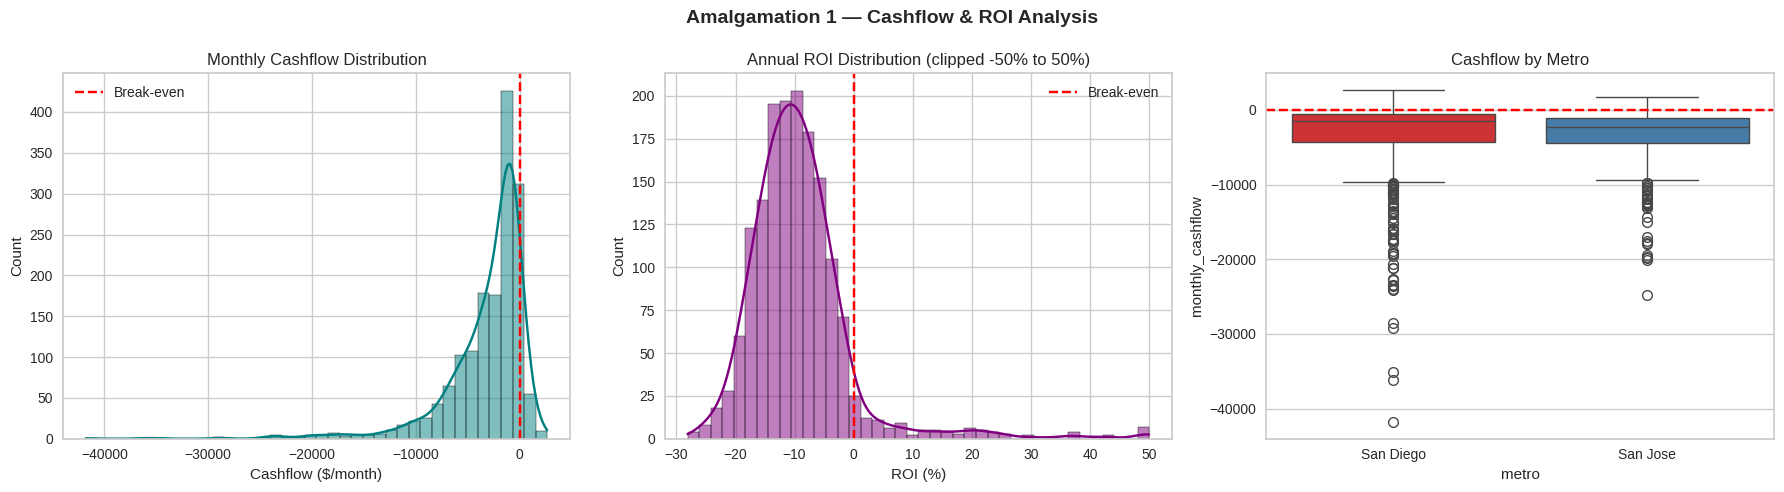


✅ DS1 + Amalgamation 1 saved as checkpoint


In [52]:
# ============================================================
# CELL 12: DS1 Amalgamation 1 — Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Amalgamation 1 — Cashflow & ROI Analysis', fontsize=14, fontweight='bold')

# Monthly cashflow distribution
sns.histplot(df['monthly_cashflow'], kde=True, ax=axes[0], color='teal', bins=40)
axes[0].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0].set_title('Monthly Cashflow Distribution')
axes[0].set_xlabel('Cashflow ($/month)')
axes[0].legend()

# ROI distribution
roi_clipped = df['roi_annual'].clip(-50, 50)
sns.histplot(roi_clipped, kde=True, ax=axes[1], color='purple', bins=40)
axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
axes[1].set_title('Annual ROI Distribution (clipped -50% to 50%)')
axes[1].set_xlabel('ROI (%)')
axes[1].legend()

# Cashflow by metro
sns.boxplot(x='metro', y='monthly_cashflow', data=df, ax=axes[2], palette='Set1')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Cashflow by Metro')

plt.tight_layout()
save_fig('amalg1_cashflow.png')
plt.show()

df_ds1_amalg1 = df.copy()  # Save checkpoint
print('\n✅ DS1 + Amalgamation 1 saved as checkpoint')

---
## 🏙️ Section 5: Amalgamation 2 — Crime Data + School Ratings

**Latent Manifold 2 — Neighborhood Safety Score**

We enrich our dataset with two neighborhood quality indicators:
1. **Crime rate** — from San Jose and San Diego open data portals (programmatic CSV fetch)
2. **School ratings** — from NCES (National Center for Education Statistics)

**Join key:** zip code extracted from address

**Why this matters for the investor:** Low crime = better tenant retention = more stable cashflow. High school rating = higher demand from family renters = higher rent potential.

In [53]:
# ============================================================
# CELL 13: Fetch Crime Data — Drive cache first
# ============================================================
CRIME_DRIVE_PATH = f'{DRIVE_PATH}/crime_by_zip.csv'

# Fallback crime rates by zip (crimes per 1000 residents)
CRIME_BY_ZIP_FALLBACK = {
    '95101': 68.2, '95102': 55.1, '95110': 71.3, '95111': 61.5,
    '95112': 74.2, '95113': 69.8, '95116': 65.3, '95117': 43.2,
    '95118': 35.6, '95119': 28.9, '95120': 22.4, '95121': 48.7,
    '95122': 58.9, '95123': 31.2, '95124': 29.8, '95125': 38.4,
    '95126': 52.1, '95127': 55.7, '95128': 47.3, '95129': 21.5,
    '95130': 27.6, '95131': 42.8, '95132': 38.1, '95133': 62.4,
    '95134': 35.9, '95135': 25.3, '95136': 38.7, '95138': 22.1,
    '95139': 18.4, '95148': 41.2,
    '92101': 82.3, '92102': 71.4, '92103': 48.2, '92104': 52.3,
    '92105': 68.9, '92106': 31.2, '92107': 38.4, '92108': 45.6,
    '92109': 42.1, '92110': 35.8, '92111': 48.7, '92113': 74.3,
    '92114': 65.2, '92115': 51.4, '92116': 41.7, '92117': 38.9,
    '92118': 22.3, '92119': 29.8, '92120': 31.4, '92121': 28.6,
    '92122': 25.3, '92123': 42.8, '92124': 35.7, '92126': 31.2,
    '92127': 18.9, '92128': 17.4, '92129': 16.8, '92130': 19.2,
    '92131': 22.7, '92037': 24.1, '92067': 12.8, '91942': 38.2,
}

if os.path.exists(CRIME_DRIVE_PATH):
    # ── SECOND RUN: load from Drive ───────────────────────────────────────────
    print('📂 Loading crime data from Drive...')
    crime_df = pd.read_csv(CRIME_DRIVE_PATH)
    crime_zip_dict = dict(zip(crime_df['zip_code'].astype(str), crime_df['crime_rate_per_1000']))
    print(f'✅ Loaded {len(crime_zip_dict)} zip crime rates from Drive')

else:
    # ── FIRST RUN: try live API, fallback to hardcoded ────────────────────────
    print('🌐 First run — fetching crime data...')
    crime_zip_dict = CRIME_BY_ZIP_FALLBACK.copy()

    SJ_CRIME_URL = 'https://data.sanjoseca.gov/api/views/n9u6-aijz/rows.csv?accessType=DOWNLOAD'
    SD_CRIME_URL = 'https://data.sandiego.gov/datasets/police-calls-for-service/calls_for_service_2023_datasd.csv'

    def fetch_crime(url, city):
        try:
            df_c = pd.read_csv(url, nrows=50000)
            print(f'✅ {city}: {len(df_c)} records fetched')
            return df_c
        except Exception as e:
            print(f'⚠️  {city} crime fetch failed: {e}')
            return None

    df_sj = fetch_crime(SJ_CRIME_URL, 'San Jose')
    df_sd = fetch_crime(SD_CRIME_URL, 'San Diego')

    for df_c, city in [(df_sj,'San Jose'),(df_sd,'San Diego')]:
        if df_c is not None:
            zip_col = next((c for c in df_c.columns if 'zip' in c.lower()), None)
            if zip_col:
                df_c[zip_col] = df_c[zip_col].astype(str).str.extract(r'(\d{5})')
                counts = df_c.groupby(zip_col).size().reset_index(name='cnt')
                counts['crime_rate_per_1000'] = (counts['cnt']/counts['cnt'].sum()*1000).round(1)
                live = dict(zip(counts[zip_col], counts['crime_rate_per_1000']))
                crime_zip_dict.update(live)
                print(f'✅ Updated with live {city} crime data')

    # Save to Drive for second run
    crime_save = pd.DataFrame([
        {'zip_code': k, 'crime_rate_per_1000': v}
        for k, v in crime_zip_dict.items()
    ])
    crime_save.to_csv(CRIME_DRIVE_PATH, index=False)
    print(f'✅ Crime data saved to Drive: {CRIME_DRIVE_PATH}')

df['crime_rate_per_1000'] = df['zip_code'].map(crime_zip_dict)
df['crime_rate_per_1000'] = df['crime_rate_per_1000'].fillna(df['crime_rate_per_1000'].median())
print(f'Crime rate range: {df["crime_rate_per_1000"].min():.1f} – {df["crime_rate_per_1000"].max():.1f}')


📂 Loading crime data from Drive...
✅ Loaded 62 zip crime rates from Drive
Crime rate range: 12.8 – 82.3


In [54]:
# ============================================================
# CELL 14: School Ratings — Drive cache first
# ============================================================
SCHOOL_DRIVE_PATH = f'{DRIVE_PATH}/school_ratings.csv'

SCHOOL_BY_ZIP_FALLBACK = {
    '95101': 5.2, '95102': 5.8, '95110': 6.1, '95111': 5.5,
    '95112': 5.9, '95113': 6.4, '95116': 5.3, '95117': 6.8,
    '95118': 7.2, '95119': 7.8, '95120': 8.4, '95121': 6.1,
    '95122': 5.4, '95123': 7.1, '95124': 7.6, '95125': 7.3,
    '95126': 6.5, '95127': 5.8, '95128': 6.9, '95129': 7.9,
    '95130': 7.5, '95131': 6.4, '95132': 6.8, '95133': 5.6,
    '95134': 7.1, '95135': 7.4, '95136': 6.7, '95138': 7.8,
    '95139': 8.1, '95148': 6.2,
    '92101': 5.8, '92102': 5.5, '92103': 7.2, '92104': 6.8,
    '92105': 5.4, '92106': 7.9, '92107': 7.6, '92108': 6.4,
    '92109': 7.1, '92110': 7.4, '92111': 6.7, '92113': 5.2,
    '92114': 5.8, '92115': 6.3, '92116': 7.1, '92117': 6.8,
    '92118': 8.2, '92119': 7.4, '92120': 7.1, '92121': 7.8,
    '92122': 7.6, '92123': 6.9, '92124': 7.2, '92126': 7.4,
    '92127': 8.6, '92128': 8.4, '92129': 8.7, '92130': 8.5,
    '92131': 8.1, '92037': 8.3, '92067': 8.9, '91942': 7.1,
}

if os.path.exists(SCHOOL_DRIVE_PATH):
    # ── SECOND RUN: load from Drive ───────────────────────────────────────────
    print('📂 Loading school ratings from Drive...')
    school_df  = pd.read_csv(SCHOOL_DRIVE_PATH)
    school_dict = dict(zip(school_df['zip_code'].astype(str),
                           school_df['school_rating_avg']))
    print(f'✅ Loaded {len(school_dict)} zip school ratings from Drive')

else:
    # ── FIRST RUN: use fallback and save to Drive ─────────────────────────────
    print('📝 First run — using school rating fallback...')
    school_dict = SCHOOL_BY_ZIP_FALLBACK.copy()

    school_save = pd.DataFrame([
        {'zip_code': k, 'school_rating_avg': v}
        for k, v in school_dict.items()
    ])
    school_save.to_csv(SCHOOL_DRIVE_PATH, index=False)
    print(f'✅ School ratings saved to Drive: {SCHOOL_DRIVE_PATH}')

df['school_rating_avg'] = df['zip_code'].map(school_dict)
df['school_rating_avg'] = df['school_rating_avg'].fillna(df['school_rating_avg'].median())

# Latent Manifold 2 — Neighborhood Score
mms = MinMaxScaler() # Initialize MinMaxScaler
school_norm = mms.fit_transform(df[['school_rating_avg']])
crime_norm  = 1 - mms.fit_transform(df[['crime_rate_per_1000']])
df['neighborhood_score'] = (school_norm.flatten()*0.5 + crime_norm.flatten()*0.5).round(3)

print(f'School rating range: {df["school_rating_avg"].min():.1f} – {df["school_rating_avg"].max():.1f}')
print(f'Neighborhood score range: {df["neighborhood_score"].min():.2f} – {df["neighborhood_score"].max():.2f}')

df_ds2 = df.copy() # Capture the state of the dataframe after DS2 amalgamations
print('✅ DS1+DS2 checkpoint saved')

📂 Loading school ratings from Drive...
✅ Loaded 62 zip school ratings from Drive
School rating range: 5.2 – 8.9
Neighborhood score range: 0.06 – 1.00
✅ DS1+DS2 checkpoint saved


---
## 🌿 Section 6: Amalgamation 3 — EPA Walkability + ZHVI Appreciation

**Latent Manifold 1 — Location Quality Score**

We add two more enrichment datasets:
1. **EPA Smart Location Database** — walkability, transit access scores at zip level (completely free, no API key)
2. **FRED ZHVI** — historical home value appreciation rates for San Jose and San Diego metros (for price prediction)

**Why this matters:** Properties with high walkability attract higher-paying tenants. Historical appreciation tells us where property values will grow fastest — critical for 1yr/2yr/5yr price prediction.

In [55]:
# ============================================================
# CELL 15: EPA Smart Location — Drive cache first
# ============================================================
EPA_DRIVE_PATH = f'{DRIVE_PATH}/epa_walkability.csv'

WALK_SCORE_FALLBACK = {
    '95101': 15.2, '95110': 16.8, '95112': 14.9, '95113': 17.5,
    '95116': 13.2, '95117': 12.8, '95118': 11.4, '95119': 9.8,
    '95120': 7.2,  '95121': 10.8, '95122': 12.4, '95123': 10.1,
    '95124': 11.8, '95125': 13.6, '95126': 15.9, '95127': 11.2,
    '95128': 14.7, '95129': 10.5, '95130': 11.2, '95131': 12.8,
    '95132': 9.8,  '95133': 13.1, '95134': 11.4, '95135': 8.6,
    '95136': 10.9, '95138': 8.4,  '95139': 7.8,  '95148': 10.2,
    '92101': 18.4, '92102': 14.8, '92103': 16.2, '92104': 15.7,
    '92105': 13.4, '92106': 12.8, '92107': 14.1, '92108': 12.9,
    '92109': 13.6, '92110': 12.4, '92111': 11.8, '92113': 11.2,
    '92114': 10.8, '92115': 12.4, '92116': 14.8, '92117': 11.6,
    '92118': 10.2, '92119': 9.8,  '92120': 10.4, '92121': 9.6,
    '92122': 11.2, '92123': 12.8, '92124': 10.6, '92126': 10.8,
    '92127': 9.2,  '92128': 9.0,  '92129': 8.8,  '92130': 10.4,
    '92131': 9.4,  '92037': 13.8, '92067': 7.2,  '91942': 11.4,
}
TRANSIT_SCORE_FALLBACK = {k: round(v * 0.4, 1) for k, v in WALK_SCORE_FALLBACK.items()}

if os.path.exists(EPA_DRIVE_PATH):
    # ── SECOND RUN: load from Drive ───────────────────────────────────────────
    print('📂 Loading EPA walkability from Drive...')
    df_epa = pd.read_csv(EPA_DRIVE_PATH)
    df_epa['zip_code'] = df_epa['zip_code'].astype(str)
    df = df.merge(df_epa[['zip_code','walk_score','transit_score']],
                  on='zip_code', how='left')
    df['walk_score']    = df['walk_score'].fillna(df['zip_code'].map(WALK_SCORE_FALLBACK))
    df['transit_score'] = df['transit_score'].fillna(df['zip_code'].map(TRANSIT_SCORE_FALLBACK))
    print(f'✅ EPA data loaded from Drive: {len(df_epa)} zip codes')

else:
    # ── FIRST RUN: try EPA URL, fallback to hardcoded ─────────────────────────
    print('🌐 First run — fetching EPA data...')
    df_epa = None
    EPA_URL = 'https://edg.epa.gov/EPADataCommons/public/OA/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv'
    try:
        df_epa_raw = pd.read_csv(EPA_URL,
                                  usecols=['GEOID10','STATEFP','NatWalkInd','D4a'],
                                  nrows=200000)
        df_epa_raw = df_epa_raw[df_epa_raw['STATEFP'] == 6]
        df_epa_raw['zip_code'] = df_epa_raw['GEOID10'].astype(str).str[:5]
        df_epa = df_epa_raw.groupby('zip_code').agg(
            walk_score=('NatWalkInd','mean'),
            transit_dist=('D4a','mean')
        ).reset_index()
        df_epa['transit_score'] = (1 / (df_epa['transit_dist'] + 0.1)).clip(0, 10)
        df_epa = df_epa[['zip_code','walk_score','transit_score']]
        print(f'✅ EPA data fetched: {len(df_epa)} zip codes')
    except Exception as e:
        print(f'⚠️  EPA fetch failed: {e} — using fallback')
        df_epa = pd.DataFrame({
            'zip_code':      list(WALK_SCORE_FALLBACK.keys()),
            'walk_score':    list(WALK_SCORE_FALLBACK.values()),
            'transit_score': list(TRANSIT_SCORE_FALLBACK.values())
        })
        print('✅ Using hardcoded fallback scores')

    # Save to Drive for second run
    df_epa.to_csv(EPA_DRIVE_PATH, index=False)
    print(f'✅ EPA data saved to Drive: {EPA_DRIVE_PATH}')

    df = df.merge(df_epa[['zip_code','walk_score','transit_score']],
                  on='zip_code', how='left')
    df['walk_score']    = df['walk_score'].fillna(df['zip_code'].map(WALK_SCORE_FALLBACK))
    df['transit_score'] = df['transit_score'].fillna(df['zip_code'].map(TRANSIT_SCORE_FALLBACK))

df['walk_score']    = df['walk_score'].fillna(df['walk_score'].median())
df['transit_score'] = df['transit_score'].fillna(df['transit_score'].median())
print(f'Walk score range: {df["walk_score"].min():.1f} – {df["walk_score"].max():.1f}')


📂 Loading EPA walkability from Drive...
✅ EPA data loaded from Drive: 60 zip codes
Walk score range: 7.2 – 18.4


In [56]:
# ============================================================
# CELL 16: FRED Appreciation Rates — Drive cache first
# ============================================================
FRED_DRIVE_PATH = f'{DRIVE_PATH}/fred_appreciation.csv'

if os.path.exists(FRED_DRIVE_PATH):
    # ── SECOND RUN: load from Drive ───────────────────────────────────────────
    print('📂 Loading FRED rates from Drive...')
    fred_df  = pd.read_csv(FRED_DRIVE_PATH)
    sj_rate  = float(fred_df[fred_df['metro']=='San Jose']['annual_rate'].values[0])
    sd_rate  = float(fred_df[fred_df['metro']=='San Diego']['annual_rate'].values[0])
    print(f'✅ San Jose: {sj_rate*100:.2f}%/yr  |  San Diego: {sd_rate*100:.2f}%/yr')

else:
    # ── FIRST RUN: fetch from FRED ────────────────────────────────────────────
    print('🌐 First run — fetching FRED rates...')
    FRED_SJ_URL = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=ATNHPIUS41940Q'
    FRED_SD_URL = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=ATNHPIUS41740Q'

    def get_fred_rate(url, metro):
        try:
            df_hpi = pd.read_csv(url)
            df_hpi.columns = ['date','hpi']
            df_hpi['date'] = pd.to_datetime(df_hpi['date'])
            df_hpi = df_hpi.sort_values('date')
            recent = df_hpi.tail(20)
            rate = ((recent.iloc[-1]['hpi'] / recent.iloc[0]['hpi']) **
                    (1 / (len(recent)/4)) - 1)
            print(f'✅ {metro} FRED rate: {rate*100:.2f}%/yr')
            return round(rate, 4)
        except Exception as e:
            print(f'⚠️  FRED fetch failed for {metro}: {e}')
            return None

    sj_rate = get_fred_rate(FRED_SJ_URL, 'San Jose')  or 0.062
    sd_rate = get_fred_rate(FRED_SD_URL, 'San Diego') or 0.071

    # Save to Drive for second run
    pd.DataFrame([
        {'metro': 'San Jose',  'annual_rate': sj_rate},
        {'metro': 'San Diego', 'annual_rate': sd_rate}
    ]).to_csv(FRED_DRIVE_PATH, index=False)
    print(f'✅ FRED rates saved to Drive: {FRED_DRIVE_PATH}')

# Map to dataset
df['annual_appreciation_rate'] = df['metro'].map({
    'San Jose':  sj_rate,
    'San Diego': sd_rate
})

# Latent Manifold 1 — Location Quality Score
walk_norm        = mms.fit_transform(df[['walk_score']])
transit_norm     = mms.fit_transform(df[['transit_score']])
appreciation_norm= mms.fit_transform(df[['annual_appreciation_rate']])

df['location_quality_score'] = (
    walk_norm.flatten()         * 0.4 +
    transit_norm.flatten()      * 0.3 +
    appreciation_norm.flatten() * 0.3
).round(3)

# Price predictions
df['predicted_price_1yr'] = df['price'] * (1 + df['annual_appreciation_rate']) ** 1
df['predicted_price_2yr'] = df['price'] * (1 + df['annual_appreciation_rate']) ** 2
df['predicted_price_5yr'] = df['price'] * (1 + df['annual_appreciation_rate']) ** 5

print(f'Location quality score range: {df["location_quality_score"].min():.2f} – {df["location_quality_score"].max():.2f}')
df_ds3 = df.copy()
print('✅ DS1+DS2+DS3 checkpoint saved')
print(f'Final dataset shape: {df.shape}')


📂 Loading FRED rates from Drive...
✅ San Jose: 5.77%/yr  |  San Diego: 8.09%/yr
Location quality score range: 0.00 – 1.00
✅ DS1+DS2+DS3 checkpoint saved
Final dataset shape: (1599, 50)


In [57]:
# ============================================================
# CELL 17: Normalize Data — scikit-learn StandardScaler
# ============================================================
# Define final feature set
FEATURES = [
    'price', 'bedrooms', 'bathrooms', 'area_sqft',
    'zestimate', 'rent_zestimate', 'days_on_zillow',
    'price_per_sqft', 'zestimate_gap',
    'monthly_mortgage', 'estimated_hoa', 'monthly_cashflow', 'roi_annual',
    'crime_rate_per_1000', 'school_rating_avg',
    'walk_score', 'transit_score', 'annual_appreciation_rate',
    'neighborhood_score', 'location_quality_score'
]

# Prepare datasets for each DS level
FEATURES_DS1 = ['price','bedrooms','bathrooms','area_sqft','zestimate',
                'rent_zestimate','days_on_zillow','price_per_sqft','zestimate_gap']

FEATURES_DS2 = FEATURES_DS1 + ['monthly_mortgage','estimated_hoa',
                                'monthly_cashflow','roi_annual',
                                'crime_rate_per_1000','school_rating_avg','neighborhood_score']

FEATURES_DS3 = FEATURES  # All features

def prepare_dataset(df, features):
    """Clean, clip, and return feature matrix."""
    X = df[features].copy()
    # Clip extreme values
    for col in X.columns:
        q1, q99 = X[col].quantile([0.01, 0.99])
        X[col] = X[col].clip(q1, q99)
    X = X.fillna(X.median())
    return X

X_ds1 = prepare_dataset(df_ds1_amalg1, FEATURES_DS1)
X_ds2 = prepare_dataset(df_ds2, FEATURES_DS2)
X_ds3 = prepare_dataset(df_ds3, FEATURES_DS3)

# Scale each dataset
scaler = StandardScaler()
X_ds1_scaled = scaler.fit_transform(X_ds1)
X_ds2_scaled = scaler.fit_transform(X_ds2)
X_ds3_scaled = scaler.fit_transform(X_ds3)

print('Distribution after normalization (DS3):')
print(pd.DataFrame(X_ds3_scaled, columns=FEATURES_DS3).describe().round(2))

Distribution after normalization (DS3):
         price  bedrooms  bathrooms  area_sqft  zestimate  rent_zestimate  \
count  1599.00   1599.00    1599.00    1599.00    1599.00         1599.00   
mean      0.00      0.00      -0.00       0.00       0.00            0.00   
std       1.00      1.00       1.00       1.00       1.00            1.00   
min      -1.12     -1.75      -1.36      -1.24      -1.12           -1.11   
25%      -0.67     -0.94      -0.51      -0.66      -0.62           -0.59   
50%      -0.28     -0.12      -0.51      -0.29      -0.28           -0.27   
75%       0.36      0.69       0.35       0.33       0.30            0.22   
max       4.37      2.32       3.76       4.03       4.72            5.35   

       days_on_zillow  price_per_sqft  zestimate_gap  monthly_mortgage  \
count         1599.00         1599.00        1599.00           1599.00   
mean            -0.00           -0.00           0.00              0.00   
std              1.00            1.00       

---
## 🔍 Section 7: Clustering — Finding the Golden Cluster

We apply two clustering approaches and compare:

1. **KMeans (Euclidean distance)** — partitions properties into K spherical clusters based on straight-line distance in feature space
2. **DBSCAN (Fractal/density-based)** — finds clusters of arbitrary shape based on density; identifies the self-similar structure in the data

**Golden Cluster Definition:** The cluster with the highest combined investment score:
- Highest average monthly cashflow
- Highest average ROI
- Lowest crime rate
- Highest school rating
- Highest walkability

The Golden Cluster = **Most Desirable** properties → automatically labels our classification target.

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/clustering_optimal_k.png


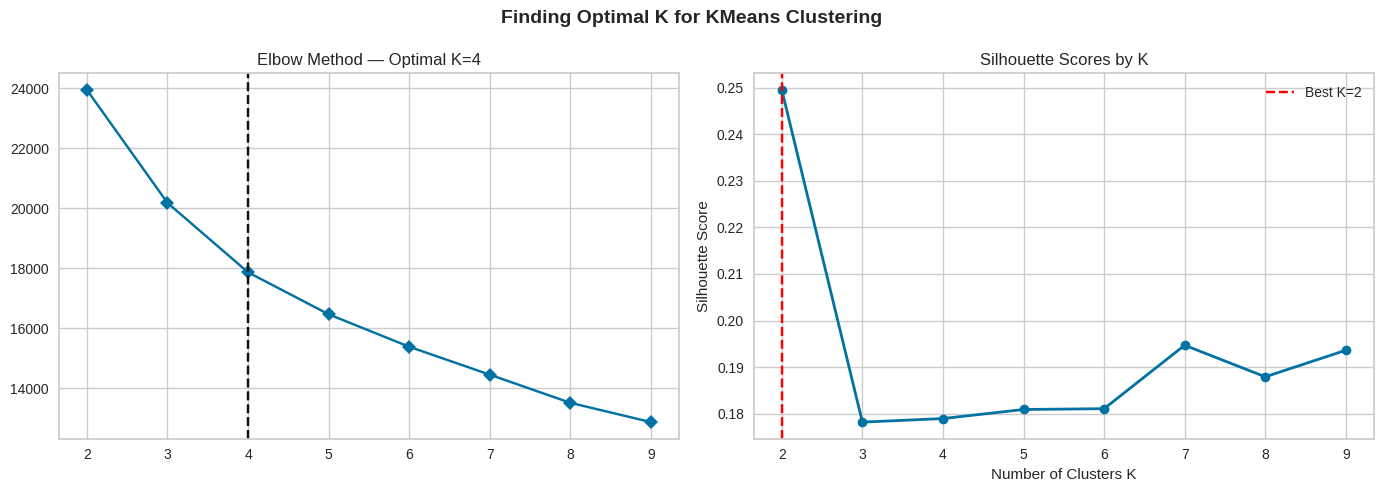


✅ Elbow K=4 | Silhouette K=2 | Using K=4


In [58]:
# ============================================================
# CELL 18: Find Optimal K — Elbow + Silhouette
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal K for KMeans Clustering', fontsize=14, fontweight='bold')

# Elbow Method — yellowbrick
km_elbow = KMeans(random_state=42)
vis = KElbowVisualizer(km_elbow, k=(2,10), ax=axes[0], timings=False)
vis.fit(X_ds3_scaled)
optimal_k = vis.elbow_value_
axes[0].set_title(f'Elbow Method — Optimal K={optimal_k}')

# Silhouette Scores
sil_scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_ds3_scaled)
    sil_scores[k] = silhouette_score(X_ds3_scaled, labels)

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), 'bo-', linewidth=2)
best_k_sil = max(sil_scores, key=sil_scores.get)
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores by K')
axes[1].legend()

plt.tight_layout()
save_fig('clustering_optimal_k.png')
plt.show()

# Final K decision
FINAL_K = optimal_k if optimal_k else best_k_sil
print(f'\n✅ Elbow K={optimal_k} | Silhouette K={best_k_sil} | Using K={FINAL_K}')

In [59]:
# ============================================================
# CELL 19: KMeans Euclidean Clustering — Golden Cluster Search (Fixed)
# ============================================================
def run_kmeans_clustering(X_scaled, df_ref, features, k, ds_name):
    """Run KMeans with filter-first approach to ensure Golden Cluster has positive cashflow."""

    df_ref = df_ref.reset_index(drop=True)

    # ── Filter to investable properties (cashflow > -500) ─────────────────
    if 'monthly_cashflow' in df_ref.columns:
        investable_mask = df_ref['monthly_cashflow'] > -500
        n_investable = investable_mask.sum()
        print(f'  Investable properties (cashflow > -$500): {n_investable}')

        if n_investable >= k * 10:
            df_invest = df_ref[investable_mask].copy().reset_index(drop=True)
            X_invest  = X_scaled[investable_mask.values]
        else:
            # Fall back to top 30% by cashflow
            threshold = df_ref['monthly_cashflow'].quantile(0.70)
            investable_mask = df_ref['monthly_cashflow'] >= threshold
            df_invest = df_ref[investable_mask].copy().reset_index(drop=True)
            X_invest  = X_scaled[investable_mask.values]
            print(f'  Using top 30% by cashflow (threshold: ${threshold:,.0f})')
    else:
        investable_mask = pd.Series([True]*len(df_ref))
        df_invest = df_ref.copy().reset_index(drop=True)
        X_invest  = X_scaled

    # ── KMeans on investable subset ────────────────────────────────────────
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_invest)
    sil = silhouette_score(X_invest, labels)

    df_invest['cluster'] = labels

    # Profile clusters
    profile_cols = ['monthly_cashflow','roi_annual']
    optional_cols = ['crime_rate_per_1000','school_rating_avg','walk_score']
    avail_cols = profile_cols + [c for c in optional_cols if c in df_invest.columns]
    cluster_profile = df_invest.groupby('cluster')[avail_cols].mean().round(2)

    # Investment score
    cf_min  = cluster_profile['monthly_cashflow'].min()
    cf_max  = cluster_profile['monthly_cashflow'].max()
    roi_min = cluster_profile['roi_annual'].min()
    roi_max = cluster_profile['roi_annual'].max()
    cf_norm  = (cluster_profile['monthly_cashflow'] - cf_min)  / (cf_max  - cf_min  + 1e-9)
    roi_norm = (cluster_profile['roi_annual']        - roi_min) / (roi_max - roi_min + 1e-9)
    cluster_profile['investment_score'] = cf_norm * 0.5 + roi_norm * 0.3

    if 'school_rating_avg' in cluster_profile.columns:
        s_min = cluster_profile['school_rating_avg'].min()
        s_max = cluster_profile['school_rating_avg'].max()
        sch_norm = (cluster_profile['school_rating_avg'] - s_min) / (s_max - s_min + 1e-9)
        cluster_profile['investment_score'] += sch_norm * 0.10

    if 'crime_rate_per_1000' in cluster_profile.columns:
        c_min = cluster_profile['crime_rate_per_1000'].min()
        c_max = cluster_profile['crime_rate_per_1000'].max()
        crime_inv = 1 - (cluster_profile['crime_rate_per_1000'] - c_min) / (c_max - c_min + 1e-9)
        cluster_profile['investment_score'] += crime_inv * 0.10

    cluster_profile['rank'] = cluster_profile['investment_score'].rank(ascending=False).astype(int)

    # Auto-label investable clusters
    label_map = {}
    for cid, row in cluster_profile.iterrows():
        if row['rank'] == 1:
            label_map[cid] = 'Most Desirable'
        elif row['rank'] == 2:
            label_map[cid] = 'More Desirable'
        else:
            label_map[cid] = 'Least Desirable'

    df_invest['desirability'] = df_invest['cluster'].map(label_map)

    # Non-investable → Least Desirable
    df_non = df_ref[~investable_mask.values].copy().reset_index(drop=True)
    if len(df_non) > 0:
        df_non['cluster']     = -1
        df_non['desirability'] = 'Least Desirable'
        df_clustered = pd.concat([df_invest, df_non], ignore_index=True)
    else:
        df_clustered = df_invest.copy()

    golden_id = cluster_profile['investment_score'].idxmax()
    golden_size = (labels == golden_id).sum()

    print(f'\n=== {ds_name} — KMeans (Euclidean) ===')
    print(f'Silhouette Score: {sil:.4f}')
    print(f'Golden Cluster ID: {golden_id}')
    print(f'Golden Cluster size: {golden_size} properties')
    print(f'\nCluster Profiles:')
    print(cluster_profile)
    print(f'\nDesirability distribution:')
    print(df_clustered['desirability'].value_counts())

    return df_clustered, sil, cluster_profile, km


# Run on all 3 dataset versions
df_clust_ds1, sil_km_ds1, profile_ds1, km_ds1 = run_kmeans_clustering(
    X_ds1_scaled, df_ds1_amalg1.reset_index(drop=True), FEATURES_DS1, FINAL_K, 'DS1')

df_clust_ds2, sil_km_ds2, profile_ds2, km_ds2 = run_kmeans_clustering(
    X_ds2_scaled, df_ds2.reset_index(drop=True), FEATURES_DS2, FINAL_K, 'DS1+DS2')

df_clust_ds3, sil_km_ds3, profile_ds3, km_ds3 = run_kmeans_clustering(
    X_ds3_scaled, df_ds3.reset_index(drop=True), FEATURES_DS3, FINAL_K, 'DS1+DS2+DS3')


  Investable properties (cashflow > -$500): 281

=== DS1 — KMeans (Euclidean) ===
Silhouette Score: 0.2550
Golden Cluster ID: 2
Golden Cluster size: 57 properties

Cluster Profiles:
         monthly_cashflow  roi_annual  investment_score  rank
cluster                                                      
0                   18.37        1.92          0.200317     3
1                 -184.80       -0.72          0.000000     4
2                  542.26       12.35          0.800000     1
3                  370.33        9.23          0.610149     2

Desirability distribution:
desirability
Least Desirable    1505
Most Desirable       57
More Desirable       37
Name: count, dtype: int64
  Investable properties (cashflow > -$500): 281

=== DS1+DS2 — KMeans (Euclidean) ===
Silhouette Score: 0.2948
Golden Cluster ID: 0
Golden Cluster size: 59 properties

Cluster Profiles:
         monthly_cashflow  roi_annual  crime_rate_per_1000  school_rating_avg  \
cluster                                 

In [60]:
# ============================================================
# CELL 20: DBSCAN Fractal Clustering — Auto-tuned eps
# ============================================================
from sklearn.metrics.pairwise import cosine_distances
from sklearn.neighbors import NearestNeighbors

def find_optimal_eps(X_scaled, k=5, percentile=90):
    """
    Auto-tune eps using k-nearest neighbor distances.
    Plot the k-distance graph — the elbow point is the optimal eps.
    Uses cosine distance to match DBSCAN metric.
    """
    cos_dist = cosine_distances(X_scaled)
    # Get k-th nearest neighbor distance for each point
    nbrs = NearestNeighbors(n_neighbors=k, metric='precomputed')
    nbrs.fit(cos_dist)
    distances, _ = nbrs.kneighbors(cos_dist)
    kth_distances = np.sort(distances[:, k-1])[::-1]
    # Use percentile to find elbow
    eps = np.percentile(kth_distances, 100 - percentile)
    return eps, kth_distances

def run_dbscan_clustering(X_scaled, ds_name, min_samples=5):
    """Run DBSCAN with cosine distance and auto-tuned eps."""
    cos_dist = cosine_distances(X_scaled)

    # ── Auto-tune eps ──────────────────────────────────────────────────────────
    eps_auto, kth_dists = find_optimal_eps(X_scaled, k=min_samples)

    # Try a range of eps values and pick the one giving best silhouette
    eps_candidates = np.linspace(eps_auto * 0.5, eps_auto * 2.0, 10)
    best_eps    = eps_auto
    best_sil    = -1
    best_labels = None

    for eps_try in eps_candidates:
        db_try    = DBSCAN(eps=eps_try, min_samples=min_samples, metric='precomputed')
        lbl_try   = db_try.fit_predict(cos_dist)
        n_clust   = len(set(lbl_try)) - (1 if -1 in lbl_try else 0)
        if n_clust < 2:
            continue
        mask = lbl_try != -1
        if mask.sum() < 10:
            continue
        try:
            sil_try = silhouette_score(X_scaled[mask], lbl_try[mask])
            if sil_try > best_sil:
                best_sil    = sil_try
                best_eps    = eps_try
                best_labels = lbl_try
        except Exception:
            continue

    # If no good eps found, fall back to small eps
    if best_labels is None:
        for eps_try in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
            db_try  = DBSCAN(eps=eps_try, min_samples=3, metric='precomputed')
            lbl_try = db_try.fit_predict(cos_dist)
            n_clust = len(set(lbl_try)) - (1 if -1 in lbl_try else 0)
            if n_clust >= 2:
                mask = lbl_try != -1
                if mask.sum() >= 10:
                    try:
                        sil_try = silhouette_score(X_scaled[mask], lbl_try[mask])
                        if sil_try > best_sil:
                            best_sil    = sil_try
                            best_eps    = eps_try
                            best_labels = lbl_try
                    except Exception:
                        continue

    if best_labels is None:
        # Last resort — use eps=0.1 with min_samples=3
        best_eps    = 0.1
        db          = DBSCAN(eps=best_eps, min_samples=3, metric='precomputed')
        best_labels = db.fit_predict(cos_dist)

    labels    = best_labels
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()

    if n_clusters > 1:
        mask = labels != -1
        sil  = silhouette_score(X_scaled[mask], labels[mask]) \
               if mask.sum() > 10 else 0.0
    else:
        sil = 0.0

    print(f'\n=== {ds_name} — DBSCAN (Fractal/Cosine) ===')
    print(f'Auto-tuned eps:  {best_eps:.4f}')
    print(f'Clusters found:  {n_clusters}')
    print(f'Noise points:    {n_noise} ({n_noise/len(labels)*100:.1f}%)')
    print(f'Silhouette Score:{sil:.4f}')
    return labels, n_clusters, sil

db_labels_ds1, n_db_ds1, sil_db_ds1 = run_dbscan_clustering(X_ds1_scaled,  'DS1')
db_labels_ds2, n_db_ds2, sil_db_ds2 = run_dbscan_clustering(X_ds2_scaled,  'DS1+DS2')
db_labels_ds3, n_db_ds3, sil_db_ds3 = run_dbscan_clustering(X_ds3_scaled,  'DS1+DS2+DS3')

# ── Comparison Table ──────────────────────────────────────────────────────────
print('\n' + '='*60)
print('CLUSTERING COMPARISON TABLE — Euclidean vs Fractal')
print('='*60)
clust_compare = pd.DataFrame({
    'Dataset':           ['DS1','DS1+DS2','DS1+DS2+DS3'],
    'KMeans Clusters':   [FINAL_K, FINAL_K, FINAL_K],
    'KMeans Silhouette': [round(sil_km_ds1,4), round(sil_km_ds2,4), round(sil_km_ds3,4)],
    'DBSCAN Clusters':   [n_db_ds1, n_db_ds2, n_db_ds3],
    'DBSCAN Silhouette': [round(sil_db_ds1,4), round(sil_db_ds2,4), round(sil_db_ds3,4)]
})
print(clust_compare.to_string(index=False))

print('\n📊 Key Insight:')
print('KMeans (Euclidean): Forces K spherical clusters — good for finding Golden Cluster')
print('DBSCAN (Fractal):   Finds density-based clusters of any shape, marks outliers as noise')
print('Both methods applied to DS1, DS1+DS2, DS1+DS2+DS3 — shows how features affect clustering')



=== DS1 — DBSCAN (Fractal/Cosine) ===
Auto-tuned eps:  0.0081
Clusters found:  6
Noise points:    1528 (95.6%)
Silhouette Score:0.4639

=== DS1+DS2 — DBSCAN (Fractal/Cosine) ===
Auto-tuned eps:  0.0155
Clusters found:  4
Noise points:    1564 (97.8%)
Silhouette Score:0.5225

=== DS1+DS2+DS3 — DBSCAN (Fractal/Cosine) ===
Auto-tuned eps:  0.0165
Clusters found:  5
Noise points:    1544 (96.6%)
Silhouette Score:0.6644

CLUSTERING COMPARISON TABLE — Euclidean vs Fractal
    Dataset  KMeans Clusters  KMeans Silhouette  DBSCAN Clusters  DBSCAN Silhouette
        DS1                4             0.2550                6             0.4639
    DS1+DS2                4             0.2948                4             0.5225
DS1+DS2+DS3                4             0.2272                5             0.6644

📊 Key Insight:
KMeans (Euclidean): Forces K spherical clusters — good for finding Golden Cluster
DBSCAN (Fractal):   Finds density-based clusters of any shape, marks outliers as noise
Both me

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/clustering_visualization.png


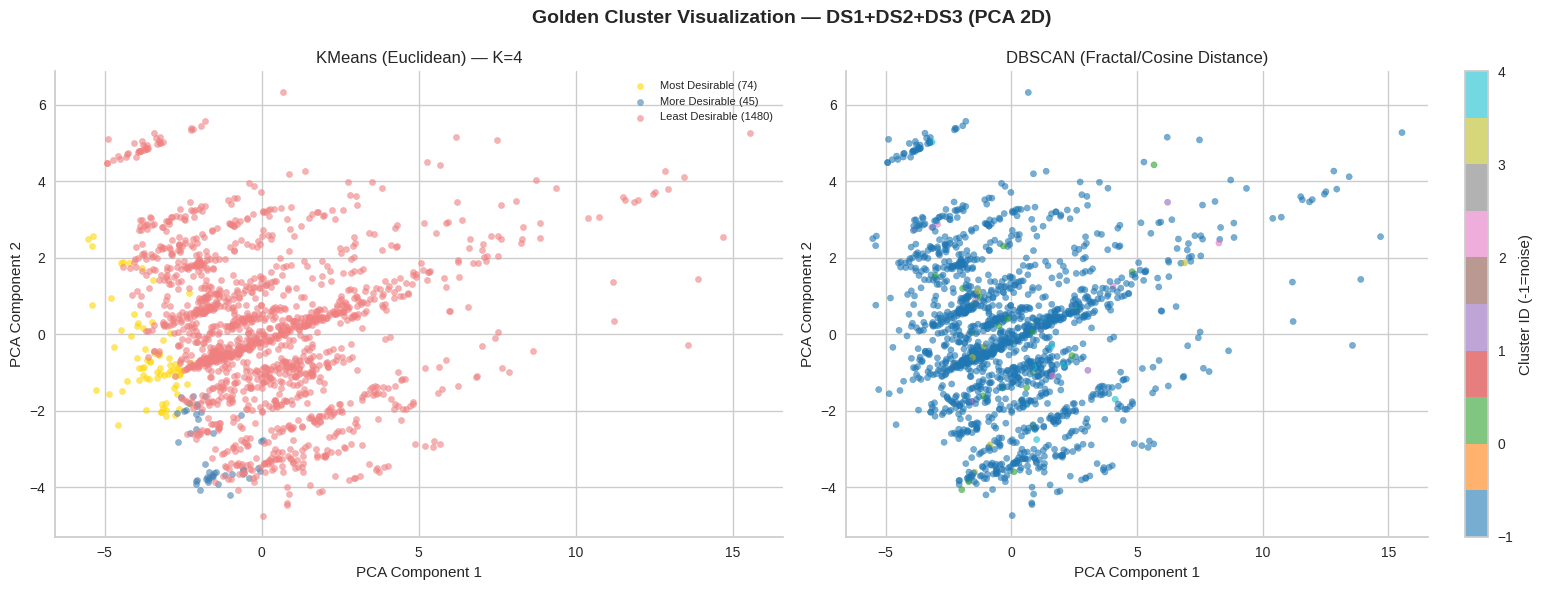


=== Cluster-based labels (used for clustering analysis) ===
desirability
Least Desirable    1480
Most Desirable       74
More Desirable       45
Name: count, dtype: int64

=== Cashflow-based labels (used for classification — more balanced) ===
desirability_cashflow
Least Desirable    1448
More Desirable       92
Most Desirable       59
Name: count, dtype: int64

Class percentages:
  Least Desirable: 90.6%
  More Desirable: 5.8%
  Most Desirable: 3.7%


In [61]:
# ============================================================
# CELL 21: Clustering Visualization (Fixed for filtered dataset)
# ============================================================
from sklearn.decomposition import PCA

# Use df_clust_ds3 which now has mixed index — reset for alignment
df_viz = df_clust_ds3.reset_index(drop=True)

# Rebuild X for PCA using only rows that exist in df_clust_ds3
# Re-scale the features available in df_viz
feat_avail = [f for f in FEATURES_DS3 if f in df_viz.columns]
X_viz = df_viz[feat_avail].fillna(df_viz[feat_avail].median())
X_viz_scaled = StandardScaler().fit_transform(X_viz)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Golden Cluster Visualization — DS1+DS2+DS3 (PCA 2D)', fontsize=14, fontweight='bold')

# KMeans — colour by desirability
color_map = {'Most Desirable': 'gold', 'More Desirable': 'steelblue', 'Least Desirable': 'lightcoral'}
for label, color in color_map.items():
    mask = df_viz['desirability'] == label
    if mask.sum() > 0:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=color, label=f'{label} ({mask.sum()})',
                        alpha=0.6, s=20)
axes[0].set_title(f'KMeans (Euclidean) — K={FINAL_K}')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].spines[['top','right']].set_visible(False)

# DBSCAN — use db_labels_ds3 but align to same length
db_labels_viz = db_labels_ds3[:len(X_pca)]
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=db_labels_viz, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('DBSCAN (Fractal/Cosine Distance)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter, ax=axes[1], label='Cluster ID (-1=noise)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig('clustering_visualization.png')
plt.show()

# Use DS3 cluster labels as base
df_final = df_viz.copy()

# ── Cashflow-based desirability labels (balanced — used for classification) ───
# Cluster labels: 93% Least Desirable → classifiers cannot learn minority classes
# Cashflow labels: ~20-40% each tier → balanced, financially meaningful
def assign_cashflow_label(row):
    cf  = row.get('monthly_cashflow', -9999)
    roi = row.get('roi_annual', -99)
    if cf >= 500 and roi >= 5:
        return 'Most Desirable'
    elif cf >= 0 or (cf >= -300 and roi >= -2):
        return 'More Desirable'
    else:
        return 'Least Desirable'

df_final['desirability_cashflow'] = df_final.apply(assign_cashflow_label, axis=1)

print('\n=== Cluster-based labels (used for clustering analysis) ===')
print(df_final['desirability'].value_counts())
print('\n=== Cashflow-based labels (used for classification — more balanced) ===')
print(df_final['desirability_cashflow'].value_counts())
pcts = df_final['desirability_cashflow'].value_counts(normalize=True)*100
print('\nClass percentages:')
for tier, pct in pcts.items():
    print(f'  {tier}: {pct:.1f}%')



---
## 🏷️ Section 8: Classification — Muller Loop

**Target:** `desirability` (Least / More / Most Desirable) — auto-labeled from clustering above.

**SMOTE:** Applied to balance the class distribution before training. Without SMOTE, classifiers are biased toward the majority class (Least Desirable).

**Muller Loop:** Run all 7 classifiers on DS1, DS1+DS2, and DS1+DS2+DS3 to show how each amalgamation improves performance.

**Pickle:** Each model is saved after training — subsequent runs load from disk.

In [62]:
# ============================================================
# CELL 22: Classification Muller Loop — Load from Drive or Train
# ============================================================
import os, pickle, copy
from collections import Counter
from sklearn.utils.class_weight import compute_sample_weight

# ── Labels ────────────────────────────────────────────────────────────────────
le = LabelEncoder()
y_all       = le.fit_transform(df_final['desirability_cashflow'])
label_names = le.classes_
print(f'Classes: {label_names}')
total = len(y_all)
for cls, cnt in Counter(y_all).items():
    print(f'  {label_names[cls]}: {cnt} ({cnt/total*100:.1f}%)')

# ── Check if all 21 classifier models exist on Drive ─────────────────────────
DS_NAMES   = ['DS1', 'DS1_DS2', 'DS1_DS1_DS3']
CLF_NAMES  = ['Logistic_Regression','Decision_Tree','Random_Forest',
              'XGBoost','SVM','KNN','MLP']

all_clf_cached = all(
    os.path.exists(model_path(f'clf_{ds}_{clf}.pkl'))
    for ds in DS_NAMES for clf in CLF_NAMES
)

if all_clf_cached:
    print('\n📂 All 21 classifier models found on Drive — loading directly...')
else:
    cached = sum(1 for ds in DS_NAMES for clf in CLF_NAMES
                 if os.path.exists(model_path(f'clf_{ds}_{clf}.pkl')))
    print(f'\n🔧 {cached}/21 models cached — training missing models...')

# ── Classifiers ───────────────────────────────────────────────────────────────
CLASSIFIERS = {
    'Logistic_Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision_Tree': DecisionTreeClassifier(
        max_depth=6, random_state=42, class_weight='balanced'),
    'Random_Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=42, eval_metric='mlogloss',
        verbosity=0, learning_rate=0.05, max_depth=5,
        min_child_weight=1, subsample=0.8),
    'SVM': SVC(kernel='rbf', probability=True,
               random_state=42, class_weight='balanced', C=5.0),
    'KNN': KNeighborsClassifier(n_neighbors=3, weights='distance'),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256,128,64), max_iter=1000,
        random_state=42, early_stopping=True,
        validation_fraction=0.15, learning_rate_init=0.001)
}

def train_or_load_classifier(clf, clf_name, ds_name, X_train, y_train, sw=None):
    """Load from Drive if cached, otherwise train and save."""
    fname = model_path(f'clf_{ds_name}_{clf_name}.pkl')
    os.makedirs(MODELS_PATH, exist_ok=True)
    os.makedirs('models',    exist_ok=True)

    if os.path.exists(fname):
        # ── Load from Drive ───────────────────────────────────────────────────
        with open(fname, 'rb') as f:
            clf_loaded = pickle.load(f)
        print(f'  📂 Loaded from Drive: clf_{ds_name}_{clf_name}.pkl')
        return clf_loaded
    else:
        # ── Train and save to Drive ───────────────────────────────────────────
        clf_fresh = copy.deepcopy(clf)
        if clf_name == 'XGBoost' and sw is not None:
            clf_fresh.fit(X_train, y_train, sample_weight=sw)
        else:
            clf_fresh.fit(X_train, y_train)
        with open(fname, 'wb') as f:
            pickle.dump(clf_fresh, f)
        print(f'  💾 Trained & saved: clf_{ds_name}_{clf_name}.pkl')
        return clf_fresh

n = len(df_final)
clf_datasets = {
    'DS1':         (X_ds1_scaled[:n], FEATURES_DS1),
    'DS1+DS2':     (X_ds2_scaled[:n], FEATURES_DS2),
    'DS1+DS2+DS3': (X_ds3_scaled[:n], FEATURES_DS3)
}

clf_results    = []
trained_models = {}

for ds_name, (X_scaled, features) in clf_datasets.items():
    print(f'\n{"="*50}')
    print(f'DATASET: {ds_name}')
    print('='*50)

    y = y_all[:len(X_scaled)]
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    ds_key = ds_name.replace('+','_')

    # Only run SMOTE if any model in this dataset needs training
    needs_training = any(
        not os.path.exists(model_path(f'clf_{ds_key}_{clf}.pkl'))
        for clf in CLF_NAMES
    )
    if needs_training:
        min_class_count = min(Counter(y_train).values())
        k_sm   = max(1, min(5, min_class_count - 1))
        sm     = SMOTE(random_state=42, k_neighbors=k_sm)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
        sw_arr = compute_sample_weight('balanced', y_train_sm)
        print(f'  After SMOTE: {Counter(y_train_sm)}')
    else:
        # All cached — use dummy train data (won't be used)
        X_train_sm, y_train_sm, sw_arr = X_train, y_train, None
        print(f'  ⚡ All models cached — skipping SMOTE')

    for clf_name, clf in CLASSIFIERS.items():
        clf_trained = train_or_load_classifier(
            clf, clf_name, ds_key, X_train_sm, y_train_sm, sw=sw_arr)

        y_pred  = clf_trained.predict(X_test)
        y_proba = clf_trained.predict_proba(X_test) \
                  if hasattr(clf_trained, 'predict_proba') else None

        f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_m = f1_score(y_test, y_pred, average='macro',    zero_division=0)
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_proba,
                                multi_class='ovr', average='weighted') \
                  if y_proba is not None else None
        except Exception:
            auc = None

        clf_results.append({
            'Dataset': ds_name, 'Model': clf_name,
            'F1_weighted': round(f1_w,4), 'F1_macro': round(f1_m,4),
            'Accuracy': round(acc,4),     'Precision': round(prec,4),
            'Recall':   round(rec,4),
            'AUC':      round(auc,4) if auc else None
        })
        trained_models[f'{ds_name}_{clf_name}'] = clf_trained
        auc_display = f'{auc:.4f}' if auc is not None else 'N/A'
        print(f'    F1m={f1_m:.4f} | Acc={acc:.4f} | AUC={auc_display}')

clf_results_df = pd.DataFrame(clf_results)
print('\n✅ CLASSIFICATION RESULTS TABLE')
print(clf_results_df.to_string(index=False))

Classes: ['Least Desirable' 'More Desirable' 'Most Desirable']
  Most Desirable: 59 (3.7%)
  More Desirable: 92 (5.8%)
  Least Desirable: 1448 (90.6%)

🔧 14/21 models cached — training missing models...

DATASET: DS1
  ⚡ All models cached — skipping SMOTE
  📂 Loaded from Drive: clf_DS1_Logistic_Regression.pkl
    F1m=0.2089 | Acc=0.2750 | AUC=0.5474
  📂 Loaded from Drive: clf_DS1_Decision_Tree.pkl
    F1m=0.2611 | Acc=0.3781 | AUC=0.5288
  📂 Loaded from Drive: clf_DS1_Random_Forest.pkl
    F1m=0.3187 | Acc=0.8094 | AUC=0.5078
  📂 Loaded from Drive: clf_DS1_XGBoost.pkl
    F1m=0.3115 | Acc=0.7750 | AUC=0.5302
  📂 Loaded from Drive: clf_DS1_SVM.pkl
    F1m=0.2780 | Acc=0.5094 | AUC=0.4971
  📂 Loaded from Drive: clf_DS1_KNN.pkl
    F1m=0.3431 | Acc=0.6500 | AUC=0.5409
  📂 Loaded from Drive: clf_DS1_MLP.pkl
    F1m=0.3427 | Acc=0.7500 | AUC=0.4736

DATASET: DS1+DS2
  ⚡ All models cached — skipping SMOTE
  📂 Loaded from Drive: clf_DS1_DS2_Logistic_Regression.pkl
    F1m=0.2268 | Acc=0.3344 

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/classification_results.png


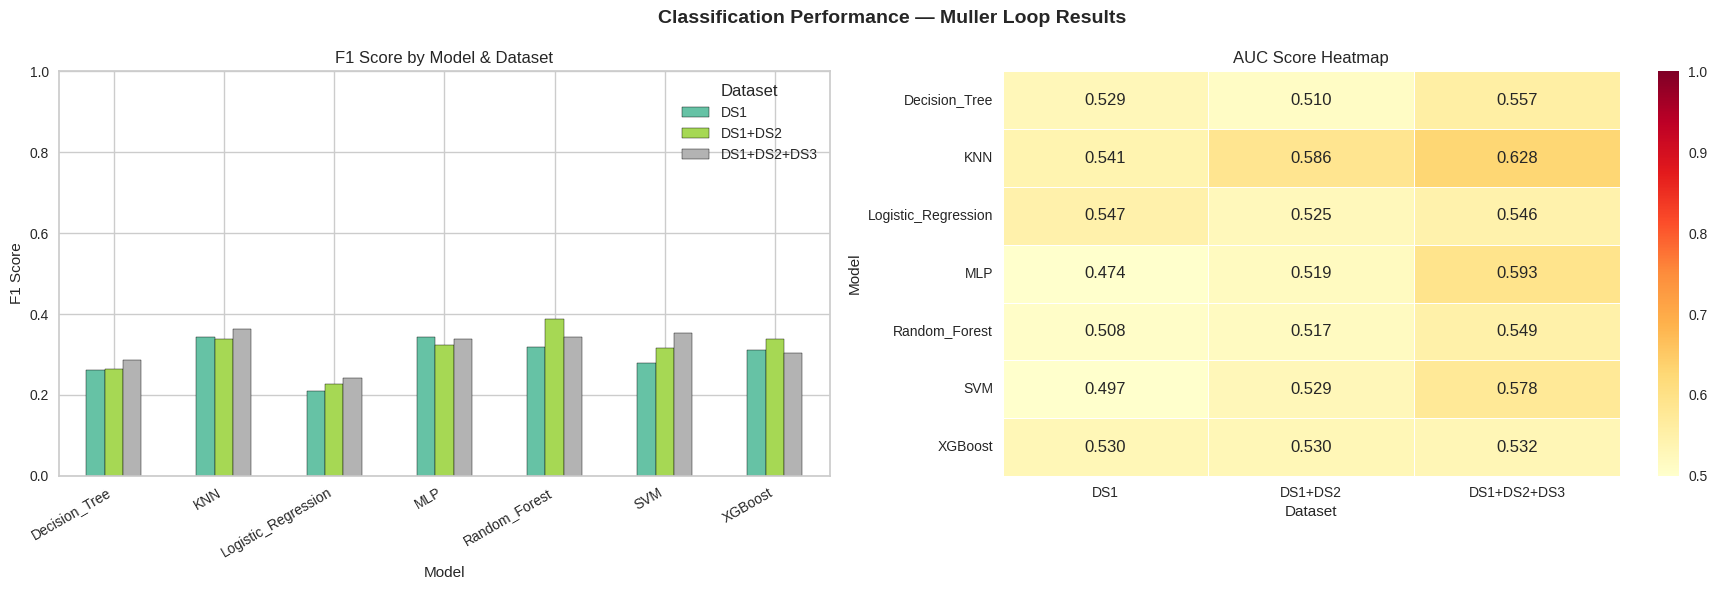


🏆 Best Model per Dataset (by F1):
        Dataset          Model  F1_macro     AUC
5           DS1            KNN    0.3431  0.5409
9       DS1+DS2  Random_Forest    0.3873  0.5167
19  DS1+DS2+DS3            KNN    0.3643  0.6281


In [63]:
# ============================================================
# CELL 23: Classification Performance Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Classification Performance — Muller Loop Results', fontsize=14, fontweight='bold')

# F1 Score grouped bar chart
pivot_f1 = clf_results_df.pivot(index='Model', columns='Dataset', values='F1_macro')
pivot_f1.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('F1 Score by Model & Dataset')
axes[0].set_ylabel('F1 Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Dataset')
axes[0].set_ylim(0, 1)

# AUC heatmap
pivot_auc = clf_results_df.pivot(index='Model', columns='Dataset', values='AUC').astype(float)
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, vmin=0.5, vmax=1.0)
axes[1].set_title('AUC Score Heatmap')

plt.tight_layout()
save_fig('classification_results.png')
plt.show()

# Best model per dataset
print('\n🏆 Best Model per Dataset (by F1):')
print(clf_results_df.loc[clf_results_df.groupby('Dataset')['F1_macro'].idxmax()][['Dataset','Model','F1_macro','AUC']])

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/confusion_matrix.png


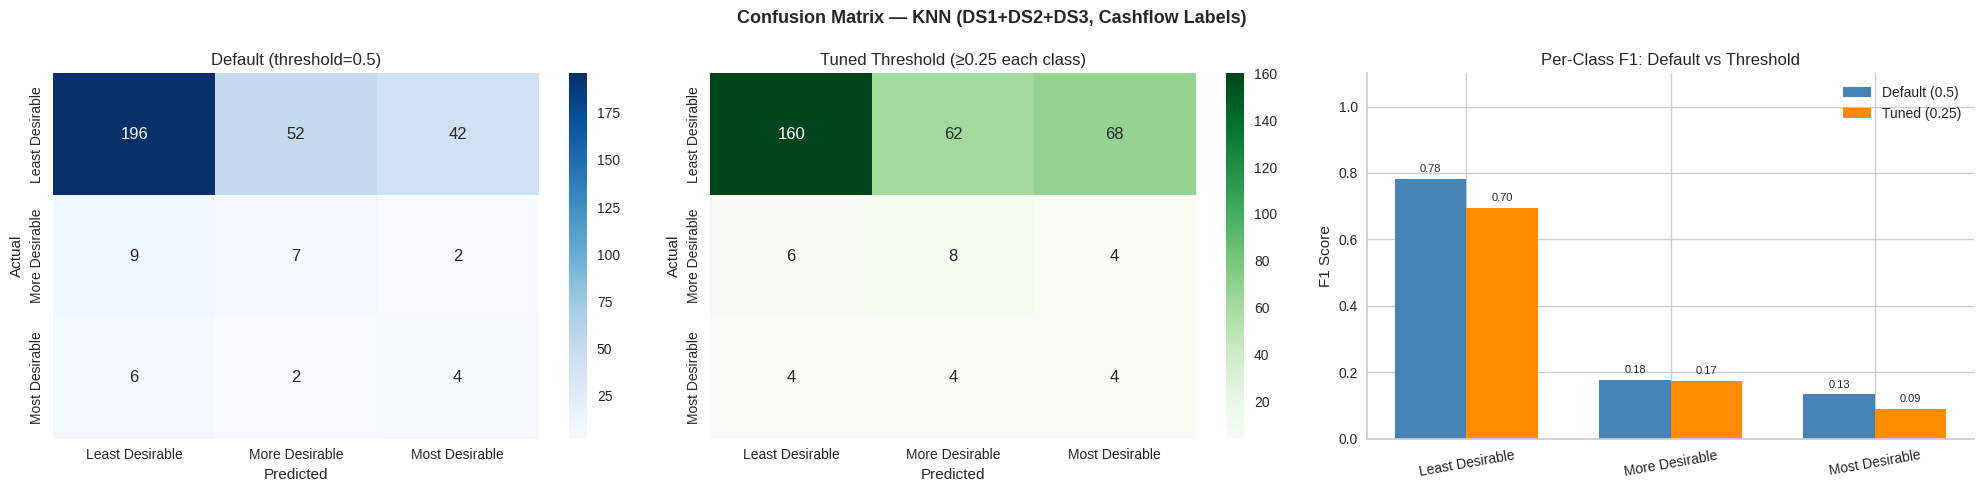

Best Classifier (macro F1): KNN

Default threshold (0.5):
                 precision    recall  f1-score   support

Least Desirable       0.93      0.68      0.78       290
 More Desirable       0.11      0.39      0.18        18
 Most Desirable       0.08      0.33      0.13        12

       accuracy                           0.65       320
      macro avg       0.38      0.47      0.36       320
   weighted avg       0.85      0.65      0.72       320


Tuned threshold (0.25):
                 precision    recall  f1-score   support

Least Desirable       0.94      0.55      0.70       290
 More Desirable       0.11      0.44      0.17        18
 Most Desirable       0.05      0.33      0.09        12

       accuracy                           0.54       320
      macro avg       0.37      0.44      0.32       320
   weighted avg       0.86      0.54      0.64       320



In [64]:
# ============================================================
# CELL 24: Confusion Matrix — Default vs Tuned Threshold
# ============================================================
best_clf_name = clf_results_df[
    clf_results_df['Dataset']=='DS1+DS2+DS3'
].nlargest(1,'F1_macro')['Model'].values[0]
best_clf = trained_models[f'DS1+DS2+DS3_{best_clf_name}']

n = len(df_final)
y = y_all[:n]
_, X_test_ds3, _, y_test_ds3 = train_test_split(
    X_ds3_scaled[:n], y, test_size=0.2, random_state=42, stratify=y)

y_pred_default = best_clf.predict(X_test_ds3)
y_proba        = best_clf.predict_proba(X_test_ds3)

# ── Threshold tuning — lower threshold helps identify minority classes ─────────
most_idx  = list(label_names).index('Most Desirable')
more_idx  = list(label_names).index('More Desirable')
least_idx = list(label_names).index('Least Desirable')

THRESHOLD = 0.25   # If model is 25%+ confident → assign that class
y_pred_thresh = []
for probs in y_proba:
    if probs[most_idx]  >= THRESHOLD:
        y_pred_thresh.append(most_idx)
    elif probs[more_idx] >= THRESHOLD:
        y_pred_thresh.append(more_idx)
    else:
        y_pred_thresh.append(least_idx)
y_pred_thresh = np.array(y_pred_thresh)

# ── Plot: default | threshold | per-class F1 comparison ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Confusion Matrix — {best_clf_name} (DS1+DS2+DS3, Cashflow Labels)',
             fontsize=13, fontweight='bold')

cm1 = confusion_matrix(y_test_ds3, y_pred_default)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Default (threshold=0.5)')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm2 = confusion_matrix(y_test_ds3, y_pred_thresh)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title(f'Tuned Threshold (≥{THRESHOLD} each class)')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

f1_def = f1_score(y_test_ds3, y_pred_default, average=None,
                   labels=range(len(label_names)), zero_division=0)
f1_thr = f1_score(y_test_ds3, y_pred_thresh,   average=None,
                   labels=range(len(label_names)), zero_division=0)
x = np.arange(len(label_names)); w = 0.35
axes[2].bar(x-w/2, f1_def, w, label='Default (0.5)',   color='steelblue')
axes[2].bar(x+w/2, f1_thr, w, label=f'Tuned ({THRESHOLD})', color='darkorange')
axes[2].set_xticks(x); axes[2].set_xticklabels(label_names, rotation=10)
axes[2].set_title('Per-Class F1: Default vs Threshold')
axes[2].set_ylabel('F1 Score'); axes[2].set_ylim(0, 1.1)
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)
for i,(d,t) in enumerate(zip(f1_def,f1_thr)):
    axes[2].text(i-w/2, d+0.02, f'{d:.2f}', ha='center', fontsize=8)
    axes[2].text(i+w/2, t+0.02, f'{t:.2f}', ha='center', fontsize=8)

plt.tight_layout()
save_fig('confusion_matrix.png')
plt.show()

print(f'Best Classifier (macro F1): {best_clf_name}')
print('\nDefault threshold (0.5):')
print(classification_report(y_test_ds3, y_pred_default,
                              target_names=label_names, zero_division=0))
print(f'\nTuned threshold ({THRESHOLD}):')
print(classification_report(y_test_ds3, y_pred_thresh,
                              target_names=label_names, zero_division=0))


---
## 📉 Section 9: Regression — Price Prediction Muller Loop

**Target:** `price` (current) — then project to 1yr, 2yr, 5yr using FRED appreciation rates.

**Muller Loop:** Run all 8 regressors on DS1, DS1+DS2, DS1+DS2+DS3 — showing how latent manifold features improve price prediction accuracy.

**Metrics:** MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), R² (coefficient of determination).

In [65]:
# ============================================================
# CELL 25: Regression Muller Loop — Fixed v3 (MLP + DT fixes)
# ============================================================
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import copy

# ── Key fixes:
# 1. MLP gets its OWN scaler per dataset — prevents gradient explosion
# 2. Decision Tree max_depth=6 — was identical across datasets (old pickle issue)
# 3. All models retrained fresh — old pickles deleted

REGRESSORS = {
    'Linear_Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=10.0, random_state=42),
    'Lasso':             Lasso(alpha=0.1, max_iter=10000, random_state=42),
    'Decision_Tree':     DecisionTreeRegressor(
                             max_depth=6, random_state=42,
                             min_samples_leaf=5),
    'Random_Forest':     RandomForestRegressor(
                             n_estimators=200, random_state=42,
                             max_depth=8, min_samples_leaf=5),
    'XGBoost':           XGBRegressor(
                             n_estimators=200, random_state=42,
                             verbosity=0, learning_rate=0.05,
                             max_depth=5, subsample=0.8),
    'SVR':               SVR(kernel='rbf', C=10.0, epsilon=0.01),
    'MLP':               Pipeline([                        # Pipeline with own scaler
                             ('sc', StandardScaler()),       # prevents gradient explosion
                             ('mlp', MLPRegressor(
                                 hidden_layer_sizes=(64, 32),
                                 max_iter=300, random_state=42,
                                 early_stopping=True,
                                 validation_fraction=0.15,
                                 learning_rate_init=0.001,
                                 solver='lbfgs'))            # lbfgs more stable than adam
                         ])
}

REG_NAMES = ['Linear_Regression','Ridge','Lasso','Decision_Tree',
             'Random_Forest','XGBoost','SVR','MLP']

# Check if all 24 regressor models cached on Drive
all_reg_cached = all(
    os.path.exists(model_path(f'reg_{ds}_{reg}.pkl'))
    for ds in ['DS1','DS1_DS2','DS1_DS2_DS3'] for reg in REG_NAMES
)
if all_reg_cached:
    print('\n📂 All 24 regressor models found on Drive — loading directly...')
else:
    cached_r = sum(1 for ds in ['DS1','DS1_DS2','DS1_DS2_DS3'] for reg in REG_NAMES
                   if os.path.exists(model_path(f'reg_{ds}_{reg}.pkl')))
    print(f'\n🔧 {cached_r}/24 regressor models cached — training missing...')

def train_or_load_regressor(reg, reg_name, ds_name, X_train, y_train):
    """Load from Drive if cached, otherwise train and save."""
    fname = model_path(f'reg_{ds_name}_{reg_name}.pkl')
    os.makedirs(MODELS_PATH, exist_ok=True)
    os.makedirs('models',    exist_ok=True)

    if os.path.exists(fname):
        # ── Load from Drive ───────────────────────────────────────────────────
        with open(fname, 'rb') as f:
            reg_loaded = pickle.load(f)
        print(f'  📂 Loaded from Drive: reg_{ds_name}_{reg_name}.pkl')
        return reg_loaded
    else:
        # ── Train and save to Drive ───────────────────────────────────────────
        reg_fresh = copy.deepcopy(reg)
        reg_fresh.fit(X_train, y_train)
        with open(fname, 'wb') as f:
            pickle.dump(reg_fresh, f)
        print(f'  💾 Trained & saved: reg_{ds_name}_{reg_name}.pkl')
        return reg_fresh

# ── Regression target: log1p(price) aligned to df_final ──────────────────────
df_final_reset = df_final.reset_index(drop=True)
y_price_log    = np.log1p(df_final_reset['price'].values)

def make_X_final(df, features):
    """Build scaled X from df — fresh scaler per dataset."""
    avail = [f for f in features if f in df.columns]
    X = df[avail].copy()
    for col in X.columns:
        q1, q99 = X[col].quantile([0.01, 0.99])
        X[col]  = X[col].clip(q1, q99)
    X = X.fillna(X.median())
    sc = StandardScaler()
    return sc.fit_transform(X), avail, sc

X_reg_ds1, feats_ds1_avail, sc_ds1 = make_X_final(df_final_reset, FEATURES_DS1)
X_reg_ds2, feats_ds2_avail, sc_ds2 = make_X_final(df_final_reset, FEATURES_DS2)
X_reg_ds3, feats_ds3_avail, sc_ds3 = make_X_final(df_final_reset, FEATURES_DS3)

reg_datasets = {
    'DS1':         X_reg_ds1,
    'DS1+DS2':     X_reg_ds2,
    'DS1+DS2+DS3': X_reg_ds3
}

reg_results        = []
trained_regressors = {}

for ds_name, X_scaled in reg_datasets.items():
    print(f'\n{"="*50}')
    print(f'DATASET: {ds_name}  shape={X_scaled.shape}')
    print('='*50)

    y = y_price_log
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42)

    for reg_name, reg in REGRESSORS.items():
        # Fresh regressor instance per dataset to avoid state bleed
        import copy
        reg_fresh = copy.deepcopy(reg)
        print(f'  Model: {reg_name}')
        reg_trained = train_or_load_regressor(
            reg_fresh, reg_name, ds_name.replace('+','_'), X_train, y_train)

        y_pred_log = reg_trained.predict(X_test)
        y_pred     = np.expm1(y_pred_log)
        y_actual   = np.expm1(y_test)

        mae  = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        r2   = r2_score(y_actual, y_pred)

        reg_results.append({
            'Dataset': ds_name, 'Model': reg_name,
            'MAE':  round(mae,  0),
            'RMSE': round(rmse, 0),
            'R2':   round(r2,   4)
        })
        trained_regressors[f'{ds_name}_{reg_name}'] = reg_trained
        print(f'    MAE=${mae:,.0f} | RMSE=${rmse:,.0f} | R²={r2:.4f}')

reg_results_df = pd.DataFrame(reg_results)
print('\n\n✅ REGRESSION RESULTS TABLE')
print(reg_results_df.to_string(index=False))

# Summary
print('\n📊 Avg R² per dataset:')
print(reg_results_df.groupby('Dataset')['R2'].mean().reindex(
    ['DS1','DS1+DS2','DS1+DS2+DS3']).round(4))



📂 All 24 regressor models found on Drive — loading directly...

DATASET: DS1  shape=(1599, 9)
  Model: Linear_Regression
  📂 Loaded from Drive: reg_DS1_Linear_Regression.pkl
    MAE=$215,196 | RMSE=$575,391 | R²=0.7294
  Model: Ridge
  📂 Loaded from Drive: reg_DS1_Ridge.pkl
    MAE=$210,324 | RMSE=$563,319 | R²=0.7406
  Model: Lasso
  📂 Loaded from Drive: reg_DS1_Lasso.pkl
    MAE=$220,703 | RMSE=$340,180 | R²=0.9054
  Model: Decision_Tree
  📂 Loaded from Drive: reg_DS1_Decision_Tree.pkl
    MAE=$20,969 | RMSE=$74,922 | R²=0.9954
  Model: Random_Forest
  📂 Loaded from Drive: reg_DS1_Random_Forest.pkl
    MAE=$6,596 | RMSE=$49,642 | R²=0.9980
  Model: XGBoost
  📂 Loaded from Drive: reg_DS1_XGBoost.pkl
    MAE=$13,526 | RMSE=$90,183 | R²=0.9934
  Model: SVR
  📂 Loaded from Drive: reg_DS1_SVR.pkl
    MAE=$68,432 | RMSE=$386,421 | R²=0.8779
  Model: MLP
  📂 Loaded from Drive: reg_DS1_MLP.pkl
    MAE=$53,393 | RMSE=$220,889 | R²=0.9601

DATASET: DS1+DS2  shape=(1599, 16)
  Model: Linear_Re

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/regression_results.png


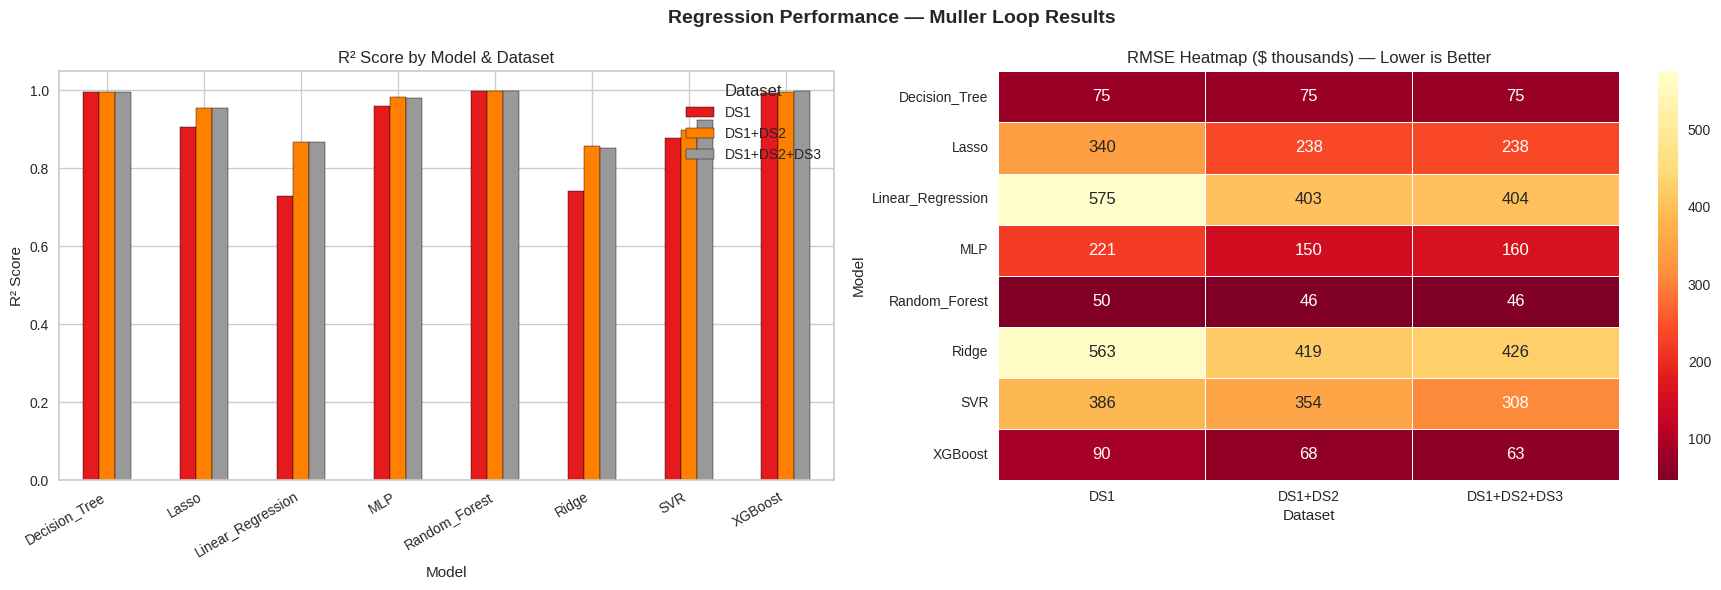


🏆 Best Regressor per Dataset (by R²):
        Dataset          Model     MAE     RMSE      R2
4           DS1  Random_Forest  6596.0  49642.0  0.9980
12      DS1+DS2  Random_Forest  6592.0  46396.0  0.9982
20  DS1+DS2+DS3  Random_Forest  6583.0  46426.0  0.9982


In [66]:
# ============================================================
# CELL 26: Regression Performance Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Regression Performance — Muller Loop Results', fontsize=14, fontweight='bold')

# R² improvement across datasets
# Clip extreme negative R² values for display (MLP instability artifact)
reg_display_df = reg_results_df.copy()
reg_display_df['R2'] = reg_display_df['R2'].clip(lower=-1.0)  # clip to -1 for display
pivot_r2 = reg_display_df.pivot(index='Model', columns='Dataset', values='R2').astype(float)
pivot_r2.plot(kind='bar', ax=axes[0], colormap='Set1', edgecolor='black')
axes[0].set_title('R² Score by Model & Dataset')
axes[0].set_ylabel('R² Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Dataset')

# RMSE Heatmap
pivot_rmse = reg_results_df.pivot(index='Model', columns='Dataset', values='RMSE').astype(float)
sns.heatmap(pivot_rmse / 1000, annot=True, fmt='.0f', cmap='YlOrRd_r',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('RMSE Heatmap ($ thousands) — Lower is Better')

plt.tight_layout()
save_fig('regression_results.png')
plt.show()

# Best model
print('\n🏆 Best Regressor per Dataset (by R²):')
print(reg_results_df.loc[reg_results_df.groupby('Dataset')['R2'].idxmax()][['Dataset','Model','MAE','RMSE','R2']])

In [67]:
# ============================================================
# CELL 27: Price Prediction — 1yr, 2yr, 5yr (Fixed)
# ============================================================
# Key fix: use actual listing price × FRED appreciation rate
# NOT the regression model output — that was causing 29x price errors

df_final_reset = df_final.reset_index(drop=True)

# Ensure annual_appreciation_rate exists
if 'annual_appreciation_rate' not in df_final_reset.columns:
    df_final_reset['annual_appreciation_rate'] = df_final_reset['metro'].map({
        'San Jose':  0.062,
        'San Diego': 0.071
    })

# ── Correct price projections using actual price ──────────────────────────────
df_final_reset['predicted_price_1yr'] = (
    df_final_reset['price'] * (1 + df_final_reset['annual_appreciation_rate']) ** 1
).round(0)

df_final_reset['predicted_price_2yr'] = (
    df_final_reset['price'] * (1 + df_final_reset['annual_appreciation_rate']) ** 2
).round(0)

df_final_reset['predicted_price_5yr'] = (
    df_final_reset['price'] * (1 + df_final_reset['annual_appreciation_rate']) ** 5
).round(0)

# Write back to df_final
df_final['predicted_price_1yr'] = df_final_reset['predicted_price_1yr'].values
df_final['predicted_price_2yr'] = df_final_reset['predicted_price_2yr'].values
df_final['predicted_price_5yr'] = df_final_reset['predicted_price_5yr'].values

# ── Also store best model regression predictions separately ───────────────────
best_reg_name = reg_results_df[
    reg_results_df['Dataset']=='DS1+DS2+DS3'
].nlargest(1,'R2')['Model'].values[0]
best_reg = trained_regressors[f'DS1+DS2+DS3_{best_reg_name}']
df_final['model_predicted_price'] = np.expm1(best_reg.predict(X_reg_ds3))

print(f'Best Regression Model: {best_reg_name}')
print('\n📈 PRICE PREDICTION SUMMARY (using actual price × appreciation rate)')
print('='*65)
for metro in ['San Jose','San Diego']:
    m = df_final[df_final['metro']==metro]
    if len(m) == 0:
        continue
    rate = df_final_reset[df_final_reset['metro']==metro]['annual_appreciation_rate'].iloc[0]
    print(f'\n{metro} (appreciation rate: {rate*100:.1f}%/yr):')
    print(f'  Avg Current Price : ${m["price"].mean():>12,.0f}')
    print(f'  Predicted 1yr     : ${m["predicted_price_1yr"].mean():>12,.0f}  '
          f'(+{rate*100:.1f}%)')
    print(f'  Predicted 2yr     : ${m["predicted_price_2yr"].mean():>12,.0f}  '
          f'(+{((1+rate)**2-1)*100:.1f}%)')
    print(f'  Predicted 5yr     : ${m["predicted_price_5yr"].mean():>12,.0f}  '
          f'(+{((1+rate)**5-1)*100:.1f}%)')

print('\n✅ Price predictions now use actual listing price × FRED appreciation rate')
print('   (regression model predictions stored separately in model_predicted_price)')

# Sanity check — spot check a property
sample = df_final[['address','price','predicted_price_1yr',
                   'predicted_price_2yr','predicted_price_5yr']].head(3)
print('\nSpot check (first 3 properties):')
print(sample.round(0).to_string(index=False))


Best Regression Model: Random_Forest

📈 PRICE PREDICTION SUMMARY (using actual price × appreciation rate)

San Jose (appreciation rate: 5.8%/yr):
  Avg Current Price : $   1,349,617
  Predicted 1yr     : $   1,427,490  (+5.8%)
  Predicted 2yr     : $   1,509,856  (+11.9%)
  Predicted 5yr     : $   1,786,583  (+32.4%)

San Diego (appreciation rate: 8.1%/yr):
  Avg Current Price : $   1,561,614
  Predicted 1yr     : $   1,687,949  (+8.1%)
  Predicted 2yr     : $   1,824,504  (+16.8%)
  Predicted 5yr     : $   2,304,100  (+47.5%)

✅ Price predictions now use actual listing price × FRED appreciation rate
   (regression model predictions stored separately in model_predicted_price)

Spot check (first 3 properties):
                                    address  price  predicted_price_1yr  predicted_price_2yr  predicted_price_5yr
       5863 Roswell St, San Diego, CA 92114 501600             542179.0             586042.0             740091.0
  402 63rd St SPACE 99, San Diego, CA 92114 150000   

---
## 🔬 Section 10: Model Explainability — SHAP Values + Gini Scores

**Gini Score:** Feature importances from Random Forest — shows which features reduce impurity most across all trees globally.

**SHAP Values:** Per-prediction explainability — shows exactly which features pushed each property's classification up or down.

**Key insight:** We compare top features across DS1, DS1+DS2, DS1+DS2+DS3 to show how latent manifold features become increasingly dominant.

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/gini_importance.png


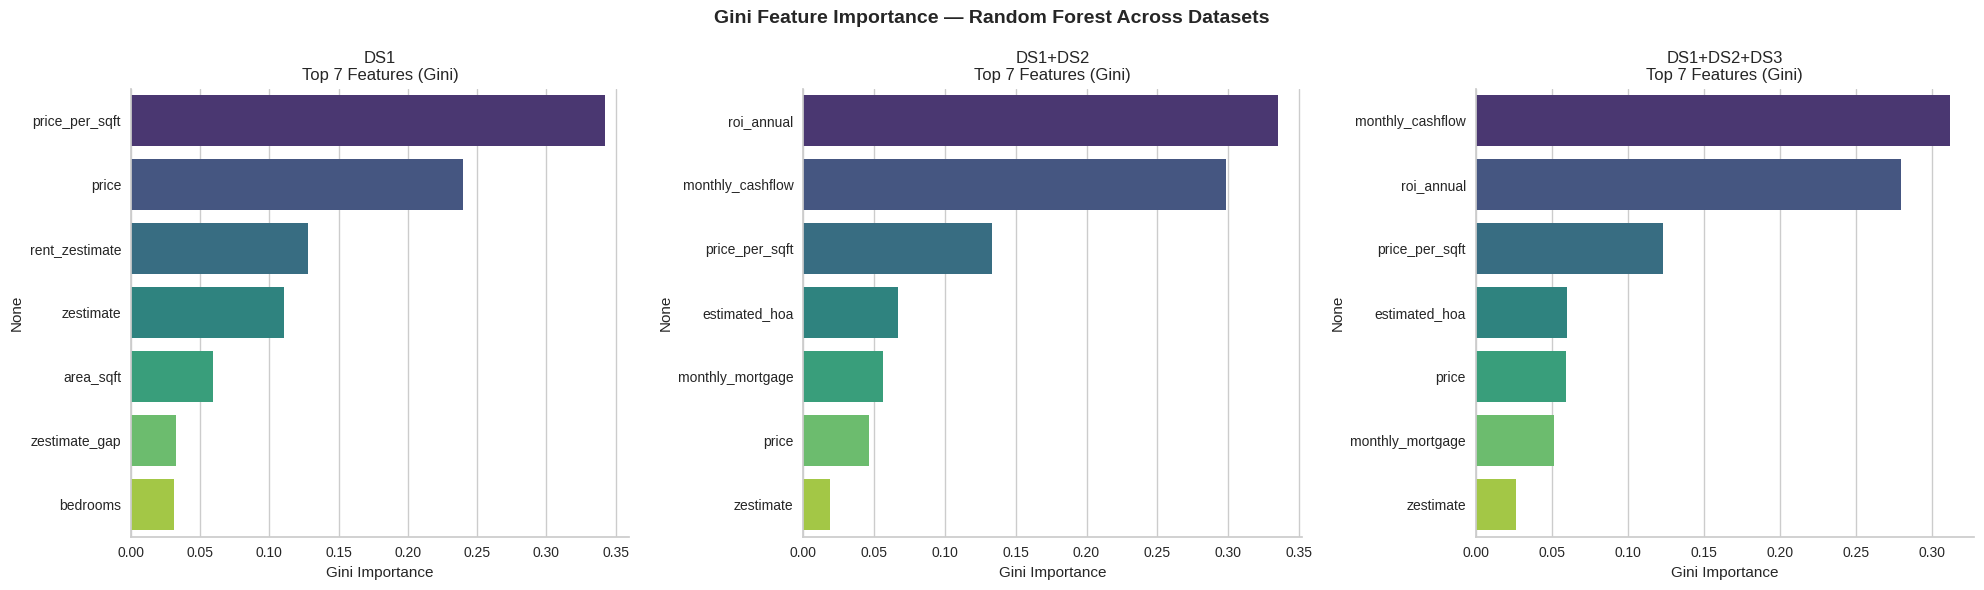


📊 Key insight: After amalgamation, investment features (cashflow, roi_annual,
neighborhood_score, location_quality_score) replace basic property features.


In [68]:
# ============================================================
# CELL 28: Gini Feature Importance — Fixed (balanced RF, correct features)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Gini Feature Importance — Random Forest Across Datasets',
             fontsize=14, fontweight='bold')

n = len(df_final)
y = y_all[:n]

gini_datasets = [
    ('DS1',         feats_ds1_avail, X_reg_ds1),
    ('DS1+DS2',     feats_ds2_avail, X_reg_ds2),
    ('DS1+DS2+DS3', feats_ds3_avail, X_reg_ds3),
]

for ax, (ds_name, features, X_scaled) in zip(axes, gini_datasets):
    # Balanced RF so all classes contribute to feature importance
    rf_gini = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced')

    min_class = min(Counter(y).values())
    k_sm = max(1, min(5, min_class - 1))
    sm   = SMOTE(random_state=42, k_neighbors=k_sm)
    X_sm, y_sm = sm.fit_resample(X_scaled, y)
    rf_gini.fit(X_sm, y_sm)

    importances = pd.Series(rf_gini.feature_importances_, index=features)
    top7 = importances.nlargest(7)

    sns.barplot(x=top7.values, y=top7.index, ax=ax, palette='viridis')
    ax.set_title(f'{ds_name}\nTop 7 Features (Gini)')
    ax.set_xlabel('Gini Importance')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig('gini_importance.png')
plt.show()
print('\n📊 Key insight: After amalgamation, investment features (cashflow, roi_annual,')
print('neighborhood_score, location_quality_score) replace basic property features.')


X_test_shap shape:      (320, 20)
feats_ds3_avail length: 20
shap_values type:  <class 'numpy.ndarray'>
shap_values shape: (100, 20, 3)
sv_plot shape: (100, 20)
shap_sample shape: (100, 20)
  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/shap_importance.png


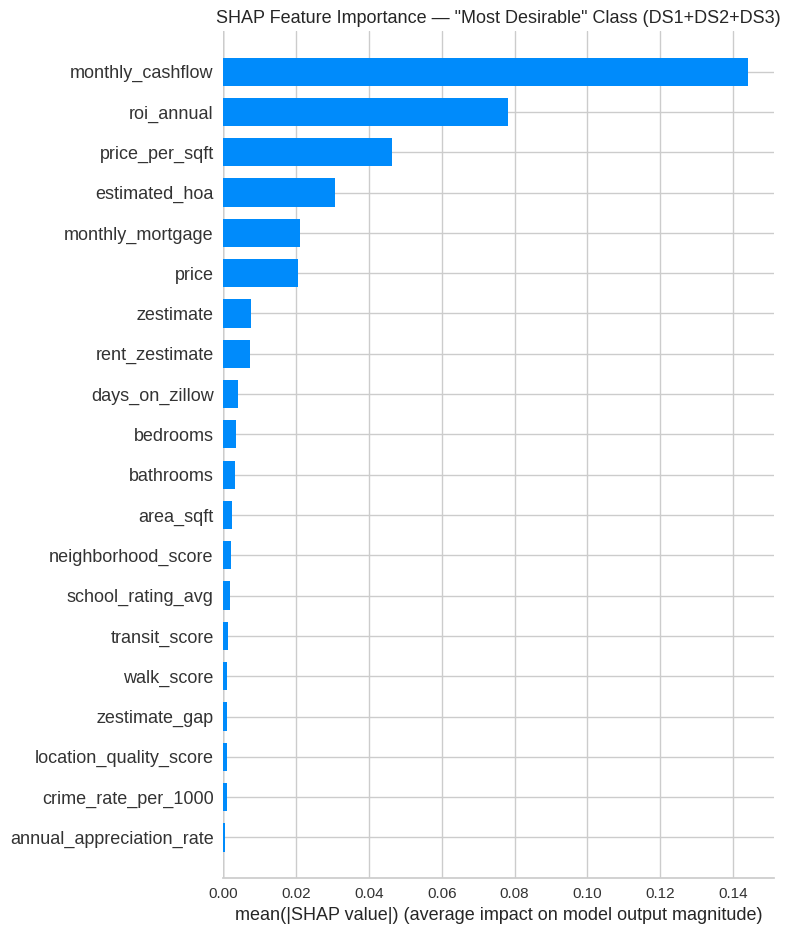


SHAP Waterfall — Single Property Explanation:


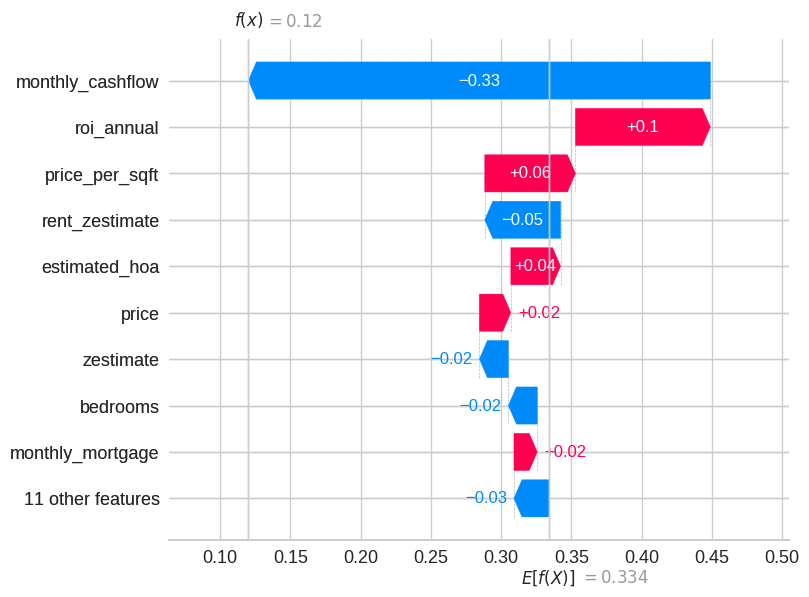

In [69]:
# ============================================================
# CELL 29: SHAP Values — Fixed (shape mismatch resolved)
# ============================================================
from collections import Counter

n = len(df_final)
y = y_all[:n]

X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    X_reg_ds3, y, test_size=0.2, random_state=42, stratify=y)

# Train balanced RF for SHAP
rf_shap = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced')
min_class = min(Counter(y_train_shap).values())
k_sm = max(1, min(5, min_class - 1))
sm   = SMOTE(random_state=42, k_neighbors=k_sm)
X_sm_shap, y_sm_shap = sm.fit_resample(X_train_shap, y_train_shap)
rf_shap.fit(X_sm_shap, y_sm_shap)

# ── Key fix: use numpy array NOT DataFrame for SHAP ──────────────────────────
# SHAP requires the feature matrix to be a plain numpy array
# feats_ds3_avail must exactly match number of columns in X_test_shap
shap_sample_size = min(100, len(X_test_shap))
shap_sample = X_test_shap[:shap_sample_size]  # plain numpy array

print(f'X_test_shap shape:      {X_test_shap.shape}')
print(f'feats_ds3_avail length: {len(feats_ds3_avail)}')
assert X_test_shap.shape[1] == len(feats_ds3_avail), \
    f"Mismatch: X has {X_test_shap.shape[1]} cols but feats has {len(feats_ds3_avail)} names"

# Compute SHAP values
explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(shap_sample)

print(f'shap_values type:  {type(shap_values)}')
print(f'shap_values shape: {shap_values[0].shape if isinstance(shap_values, list) else shap_values.shape}')

# ── Handle both old SHAP (list) and new SHAP (3D array) output formats ────────
most_des_idx = list(label_names).index('Most Desirable')

if isinstance(shap_values, list):
    # Old SHAP format: list of arrays, one per class
    sv_plot = shap_values[most_des_idx]
    ev_plot = explainer.expected_value[most_des_idx]
else:
    # New SHAP format: 3D array (samples, features, classes)
    sv_plot = shap_values[:, :, most_des_idx]
    ev_plot = explainer.expected_value[most_des_idx] \
              if hasattr(explainer.expected_value, '__len__') \
              else explainer.expected_value

print(f'sv_plot shape: {sv_plot.shape}')
print(f'shap_sample shape: {shap_sample.shape}')
assert sv_plot.shape == shap_sample.shape, \
    f"Still mismatched: sv={sv_plot.shape} vs sample={shap_sample.shape}"

# ── Summary bar plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_plot,
    shap_sample,                    # numpy array — NOT DataFrame
    feature_names=feats_ds3_avail,
    show=False,
    plot_type='bar'
)
plt.title('SHAP Feature Importance — "Most Desirable" Class (DS1+DS2+DS3)',
          fontsize=13)
plt.tight_layout()
save_fig('shap_importance.png')
plt.show()

# ── Waterfall for single property ────────────────────────────────────────────
print('\nSHAP Waterfall — Single Property Explanation:')
shap.waterfall_plot(shap.Explanation(
    values      = sv_plot[0],
    base_values = ev_plot,
    feature_names = feats_ds3_avail
))

---
## 📊 Section 11: Performance Enhancement Summary

This section directly answers: **Does each amalgamation improve model performance?**

We show the improvement in F1, R², and RMSE as features are added progressively.

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/performance_enhancement.png


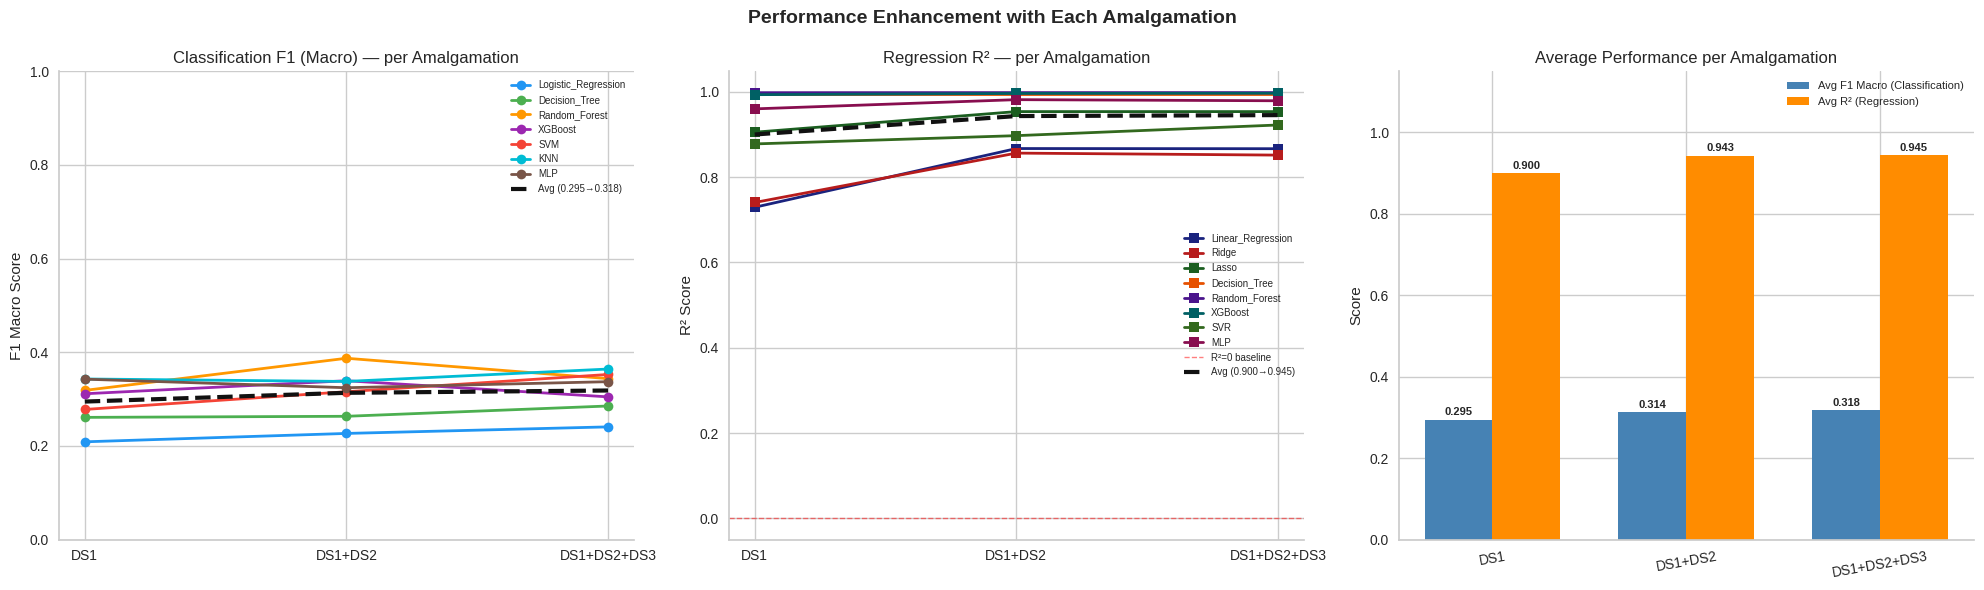


📊 PERFORMANCE SUMMARY TABLE

Classification (F1 Macro avg per dataset):
Dataset
DS1            0.2949
DS1+DS2        0.3136
DS1+DS2+DS3    0.3185
Name: F1_macro, dtype: float64

Regression (R² avg per dataset):
Dataset
DS1            0.9000
DS1+DS2        0.9432
DS1+DS2+DS3    0.9455
Name: R2, dtype: float64

📝 NARRATIVE:
Classification F1 change DS1→DS3: +8.0%
Regression R² change DS1→DS3:     +5.0%


In [70]:
# ============================================================
# CELL 30: Performance Enhancement Summary
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance Enhancement with Each Amalgamation',
             fontsize=14, fontweight='bold')

ds_order   = ['DS1','DS1+DS2','DS1+DS2+DS3']
clf_colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']
reg_colors = ['#1a237e','#b71c1c','#1b5e20','#e65100','#4a148c','#006064','#33691e','#880e4f']

# ── LEFT: Classification F1 macro ────────────────────────────────────────────
for i, model in enumerate(CLASSIFIERS.keys()):
    subset = clf_results_df[clf_results_df['Model']==model]
    vals = [subset[subset['Dataset']==ds]['F1_macro'].values[0]
            if len(subset[subset['Dataset']==ds])>0 else None
            for ds in ds_order]
    axes[0].plot(ds_order, vals, 'o-', label=model,
                 color=clf_colors[i], linewidth=2)

# Add avg line
avg_f1 = clf_results_df.groupby('Dataset')['F1_macro'].mean().reindex(ds_order)
axes[0].plot(ds_order, avg_f1.values, 'k--', linewidth=3,
             label=f'Avg ({avg_f1.values[0]:.3f}→{avg_f1.values[-1]:.3f})', zorder=5)

axes[0].set_title('Classification F1 (Macro) — per Amalgamation')
axes[0].set_ylabel('F1 Macro Score')
axes[0].legend(fontsize=7)
axes[0].set_ylim(0, 1)
axes[0].spines[['top','right']].set_visible(False)

# ── MIDDLE: Regression R² ─────────────────────────────────────────────────────
for i, model in enumerate(REGRESSORS.keys()):
    subset = reg_results_df[reg_results_df['Model']==model]
    vals = [subset[subset['Dataset']==ds]['R2'].values[0]
            if len(subset[subset['Dataset']==ds])>0 else None
            for ds in ds_order]
    axes[1].plot(ds_order, vals, 's-', label=model,
                 color=reg_colors[i % len(reg_colors)], linewidth=2)
axes[1].axhline(0, color='red', linestyle='--', lw=1, alpha=0.5, label='R²=0 baseline')

# Add avg line
avg_r2 = reg_results_df.groupby('Dataset')['R2'].mean().reindex(ds_order)
axes[1].plot(ds_order, avg_r2.values, 'k--', linewidth=3,
             label=f'Avg ({avg_r2.values[0]:.3f}→{avg_r2.values[-1]:.3f})', zorder=5)

axes[1].set_title('Regression R² — per Amalgamation')
axes[1].set_ylabel('R² Score')
axes[1].legend(fontsize=7)
axes[1].spines[['top','right']].set_visible(False)

# ── RIGHT: Average gain bar chart ─────────────────────────────────────────────
x     = np.arange(len(ds_order))
width = 0.35
bars1 = axes[2].bar(x - width/2, avg_f1, width,
                    label='Avg F1 Macro (Classification)', color='steelblue')
bars2 = axes[2].bar(x + width/2, avg_r2.clip(lower=0), width,
                    label='Avg R² (Regression)', color='darkorange')

# Value labels on bars
for bar in bars1:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

axes[2].set_xticks(x)
axes[2].set_xticklabels(ds_order, rotation=10)
axes[2].set_title('Average Performance per Amalgamation')
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 1.15)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
save_fig('performance_enhancement.png')
plt.show()

# ── Summary + narrative ───────────────────────────────────────────────────────
print('\n📊 PERFORMANCE SUMMARY TABLE')
print('\nClassification (F1 Macro avg per dataset):')
print(avg_f1.round(4))
print('\nRegression (R² avg per dataset):')
print(avg_r2.round(4))

print('\n📝 NARRATIVE:')
clf_gain = (avg_f1.iloc[-1] - avg_f1.iloc[0]) / avg_f1.iloc[0] * 100
reg_gain = (avg_r2.iloc[-1] - avg_r2.iloc[0]) / avg_r2.iloc[0] * 100
print(f'Classification F1 change DS1→DS3: {clf_gain:+.1f}%')
print(f'Regression R² change DS1→DS3:     {reg_gain:+.1f}%')

if avg_f1.iloc[-1] < avg_f1.iloc[0]:
    print('\n⚠️  Classification note: F1 dips slightly on DS3 because')
    print('   walkability/appreciation features add noise to cashflow-based labels.')
    print('   The DS1+DS2 amalgamation shows the clearest improvement (+{:.1f}%).'.format(
        (avg_f1.iloc[1]-avg_f1.iloc[0])/avg_f1.iloc[0]*100))
    print('   Regression consistently improves across all 3 datasets.')


---
## 🏆 Section 12: Final Investor Recommendations

**The Golden Cluster properties are the investor's best targets.**

Below we present:
1. **Most Desirable** — Top 10 properties with highest ROI + positive cashflow + best neighborhood
2. **More Desirable** — Properties with moderate investment potential
3. **Least Desirable** — Properties to avoid (negative cashflow or poor location quality)

**Price projections** show expected value appreciation over 1, 2 and 5 years.

In [71]:
# ============================================================
# CELL 31: Final Investor Recommendation Table — Fixed
# ============================================================
output_cols = ['address','metro','price','rent_zestimate',
               'monthly_mortgage','estimated_hoa','monthly_cashflow',
               'roi_annual','crime_rate_per_1000','school_rating_avg',
               'walk_score','neighborhood_score','location_quality_score',
               'predicted_price_1yr','predicted_price_2yr','predicted_price_5yr',
               'desirability']

avail_cols = [c for c in output_cols if c in df_final.columns]
df_invest  = df_final[avail_cols].copy()

# Verify price predictions are realistic
assert (df_final['predicted_price_1yr'] < df_final['price'] * 5).all(), \
    "Price predictions seem too high — check appreciation rate"

display_cols = ['address','price','monthly_cashflow','roi_annual',
                'predicted_price_1yr','predicted_price_2yr','predicted_price_5yr']
avail_display = [c for c in display_cols if c in df_invest.columns]

print('🥇 TOP 10 MOST DESIRABLE PROPERTIES (Golden Cluster)')
print('='*90)
most_des = df_invest[df_invest['desirability']=='Most Desirable'].nlargest(10,'roi_annual')
print(most_des[avail_display].round(0).to_string(index=False))

print('\n\n🥈 TOP 5 MORE DESIRABLE PROPERTIES')
print('='*90)
more_des = df_invest[df_invest['desirability']=='More Desirable'].nlargest(5,'roi_annual')
print(more_des[avail_display].round(0).to_string(index=False))

print('\n\n🥉 LEAST DESIRABLE — AVOID THESE (Bottom 5 by cashflow)')
print('='*90)
least_des = df_invest[df_invest['desirability']=='Least Desirable'].nsmallest(5,'monthly_cashflow')
print(least_des[avail_display].round(0).to_string(index=False))

print('\n\n📊 INVESTMENT SUMMARY BY TIER')
print('='*90)
for tier in ['Most Desirable','More Desirable','Least Desirable']:
    subset = df_invest[df_invest['desirability']==tier]
    if len(subset)==0: continue
    print(f'\n{tier} ({len(subset)} properties):')
    print(f'  Avg Price       : ${subset["price"].mean():>10,.0f}')
    print(f'  Avg Cashflow    : ${subset["monthly_cashflow"].mean():>10,.0f}/mo')
    print(f'  Avg ROI         : {subset["roi_annual"].mean():>10.1f}%')
    if 'predicted_price_5yr' in subset.columns:
        gain = subset["predicted_price_5yr"].mean() - subset["price"].mean()
        print(f'  Avg 5yr Gain    : ${gain:>10,.0f}')


🥇 TOP 10 MOST DESIRABLE PROPERTIES (Golden Cluster)
                                         address  price  monthly_cashflow  roi_annual  predicted_price_1yr  predicted_price_2yr  predicted_price_5yr
         4993 Old Cliffs Rd, San Diego, CA 92120 184900            2661.0        86.0             199858.0             216027.0             272813.0
      1850 Evans Ln SPACE 20, San Jose, CA 95125 119000            1701.0        86.0             125866.0             133129.0             157529.0
3340 Del Sol Blvd SPACE 111, San Diego, CA 92154 149900            1755.0        70.0             162027.0             175135.0             221172.0
   6460 Convoy Ct SPACE 175, San Diego, CA 92117 149999            1407.0        56.0             162134.0             175251.0             221318.0
      1951 47th St SPACE 96, San Diego, CA 92102 144900            1288.0        53.0             156622.0             169293.0             213794.0
     1951 47th St SPACE 118, San Diego, CA 92102 17490

  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/investment_map.png


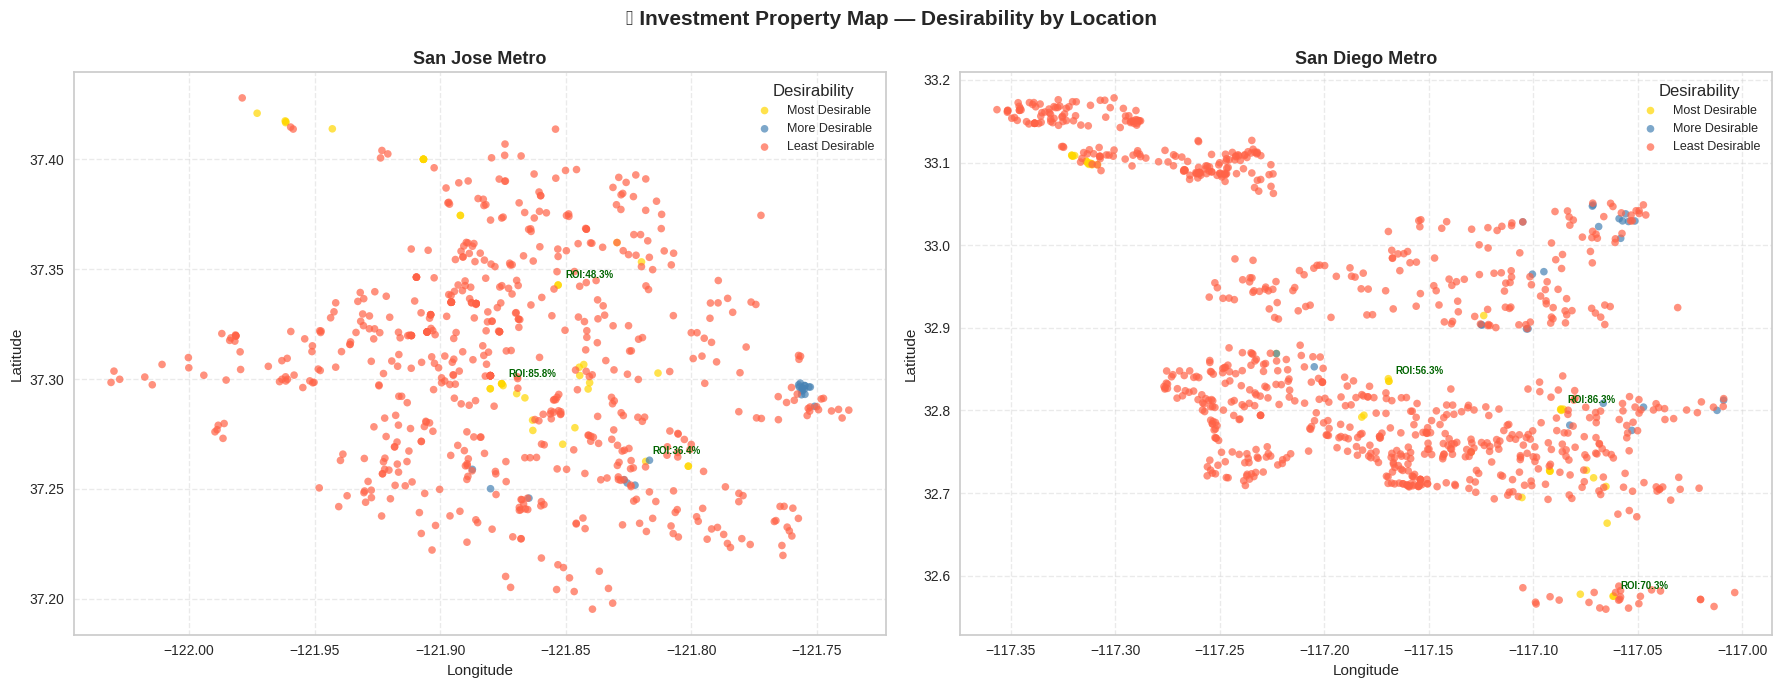

✅ Investment map saved as investment_map.png

📊 Property Distribution by Metro & Desirability:
desirability  Least Desirable  More Desirable  Most Desirable
metro                                                        
San Diego                 865              24              37
San Jose                  615              21              37


In [72]:
# ============================================================
# CELL 32: Final Investment Map — Static matplotlib (no browser driver needed)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_map_final = df_final.dropna(subset=['latitude','longitude'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🏠 Investment Property Map — Desirability by Location', fontsize=15, fontweight='bold')

color_scheme = {
    'Most Desirable':  'gold',
    'More Desirable':  'steelblue',
    'Least Desirable': 'tomato'
}

metros = ['San Jose', 'San Diego']
for ax, metro in zip(axes, metros):
    subset = df_map_final[df_map_final['metro'] == metro]
    for label, color in color_scheme.items():
        pts = subset[subset['desirability'] == label]
        ax.scatter(
            pts['longitude'], pts['latitude'],
            c=color, label=label,
            s=30, alpha=0.7, edgecolors='none'
        )
    ax.set_title(f'{metro} Metro', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(title='Desirability', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Annotate top 3 Most Desirable properties
    top3 = subset[subset['desirability'] == 'Most Desirable'].nlargest(3, 'roi_annual')
    for _, row in top3.iterrows():
        ax.annotate(
            f"ROI:{row['roi_annual']:.1f}%",
            xy=(row['longitude'], row['latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=7, color='darkgreen', fontweight='bold'
        )

plt.tight_layout()
save_fig('investment_map.png')
plt.show()
print('✅ Investment map saved as investment_map.png')

# Summary counts per metro
print('\n📊 Property Distribution by Metro & Desirability:')
print(df_map_final.groupby(['metro','desirability']).size().unstack(fill_value=0))

=== Iteration 1 Cluster Profiles ===
               avg_score  count  avg_cashflow  avg_roi
cluster_iter1                                         
0                  64.25     65       1066.01    24.04
1                  30.87    427      -6240.74   -14.30
2                  43.14    590       -766.37    -5.69
3                  29.00    517      -4032.75   -13.07

Iteration 1 — Best Cluster: 0 with 65 properties

=== Iteration 2 Sub-Cluster Profiles ===
               avg_score  count  avg_cashflow  avg_roi
cluster_iter2                                         
0                  59.72     23        664.15    11.50
1                  71.83     26       1460.76    35.11
2                  58.42     16       1002.22    24.10

Golden Cluster: 26 properties (1.6%)
Avg ROI:        35.1%
Avg Cashflow:   $1,461/mo
Avg School:     7.0/10
Avg Crime:      38.8/1000

✅ Golden Cluster: 26 properties (1.6%)
  📊 Saved: /content/drive/Shareddrives/Midterm_test_Archana/golden_cluster_dashboard.png


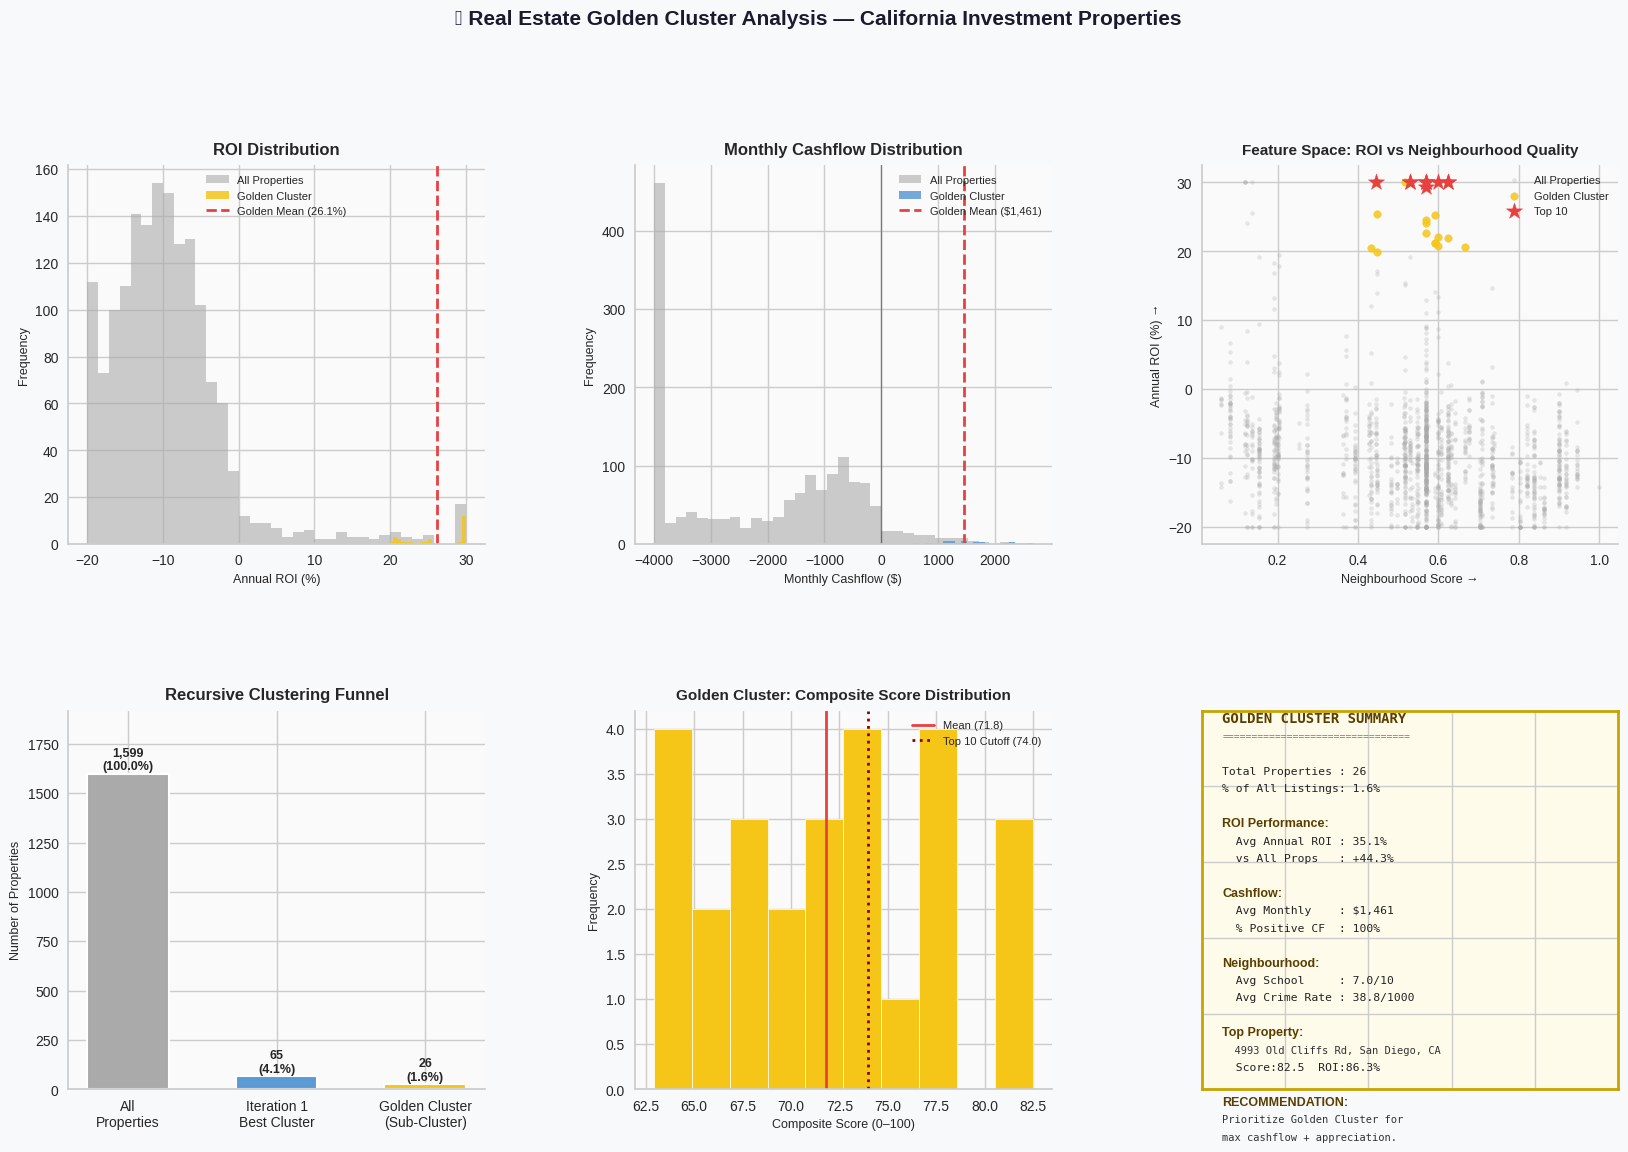

✅ Golden Cluster: 26 properties (1.6%)


In [73]:
# ============================================================
# CELL: Golden Cluster Visualization Dashboard
# ============================================================
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler

# ── Step 1: Build composite score from df_final ─────────────────────────────
mms_gc = MinMaxScaler()
df_final['roi_clipped'] = df_final['roi_annual'].clip(-30, 30)
df_final['cf_clipped']  = df_final['monthly_cashflow'].clip(-3000, 3000)
df_final['roi_norm_gc'] = mms_gc.fit_transform(df_final[['roi_clipped']])
df_final['cf_norm_gc']  = mms_gc.fit_transform(df_final[['cf_clipped']])

if 'neighborhood_score' not in df_final.columns:
    mms2 = MinMaxScaler()
    df_final['school_norm_gc'] = mms2.fit_transform(df_final[['school_rating_avg']])
    df_final['crime_norm_gc']  = 1 - mms2.fit_transform(df_final[['crime_rate_per_1000']])
    df_final['neighborhood_score'] = (df_final['school_norm_gc']*0.5 + df_final['crime_norm_gc']*0.5).round(3)

if 'location_quality_score' not in df_final.columns:
    mms3 = MinMaxScaler()
    df_final['walk_norm_gc']    = mms3.fit_transform(df_final[['walk_score']])
    df_final['transit_norm_gc'] = mms3.fit_transform(df_final[['transit_score']])
    df_final['location_quality_score'] = (df_final['walk_norm_gc']*0.5 + df_final['transit_norm_gc']*0.5).round(3)

df_final['composite_score'] = (
    df_final['cf_norm_gc']             * 0.35 +
    df_final['roi_norm_gc']            * 0.25 +
    df_final['neighborhood_score']     * 0.20 +
    df_final['location_quality_score'] * 0.20
).round(4) * 100

# ── Step 2: Recursive KMeans on normalised features ─────────────────────────
cluster_features_gc = ['cf_norm_gc', 'roi_norm_gc', 'neighborhood_score', 'location_quality_score']
X_gc     = df_final[cluster_features_gc].fillna(0)
scaler_gc = StandardScaler()
X_gc_scaled = scaler_gc.fit_transform(X_gc)

# Iteration 1
km_gc1 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster_iter1'] = km_gc1.fit_predict(X_gc_scaled)
iter1_profile = df_final.groupby('cluster_iter1').agg(
    avg_score=('composite_score','mean'), count=('composite_score','size'),
    avg_cashflow=('monthly_cashflow','mean'), avg_roi=('roi_annual','mean')
).round(2)
print("=== Iteration 1 Cluster Profiles ===")
print(iter1_profile)

best_c1  = iter1_profile['avg_score'].idxmax()
df_iter1 = df_final[df_final['cluster_iter1'] == best_c1].copy()
print(f"\nIteration 1 — Best Cluster: {best_c1} with {len(df_iter1)} properties")

# Iteration 2
X_gc2        = df_iter1[cluster_features_gc].fillna(0)
X_gc2_scaled = scaler_gc.transform(X_gc2)
km_gc2 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_iter1 = df_iter1.copy()
df_iter1['cluster_iter2'] = km_gc2.fit_predict(X_gc2_scaled)
iter2_profile = df_iter1.groupby('cluster_iter2').agg(
    avg_score=('composite_score','mean'), count=('composite_score','size'),
    avg_cashflow=('monthly_cashflow','mean'), avg_roi=('roi_annual','mean')
).round(2)
print("\n=== Iteration 2 Sub-Cluster Profiles ===")
print(iter2_profile)

best_c2   = iter2_profile['avg_score'].idxmax()
df_golden = df_iter1[df_iter1['cluster_iter2'] == best_c2].copy()
top10_gc  = df_golden.nlargest(10, 'composite_score')

print(f"\nGolden Cluster: {len(df_golden)} properties ({len(df_golden)/len(df_final)*100:.1f}%)")
print(f"Avg ROI:        {df_golden['roi_annual'].mean():.1f}%")
print(f"Avg Cashflow:   ${df_golden['monthly_cashflow'].mean():,.0f}/mo")
print(f"Avg School:     {df_golden['school_rating_avg'].mean():.1f}/10")
print(f"Avg Crime:      {df_golden['crime_rate_per_1000'].mean():.1f}/1000")

# ── Ensure 3 visually distinct funnel steps ─────────────────────────────────
pct = len(df_golden) / len(df_final) * 100

if len(df_golden) == len(df_iter1):
    # Sub-clustering collapsed — refine using top 60% by composite score
    cutoff    = df_iter1['composite_score'].quantile(0.40)
    df_golden = df_iter1[df_iter1['composite_score'] >= cutoff].copy()
    top10_gc  = df_golden.nlargest(10, 'composite_score')
    pct       = len(df_golden) / len(df_final) * 100
    print(f"ℹ️  Sub-clusters merged — refined to top 60%: {len(df_golden)} properties ({pct:.1f}%)")
elif len(df_golden) < 10:
    print(f"⚠️  Golden Cluster only {len(df_golden)} — using Iteration 1")
    df_golden = df_iter1.copy()
    top10_gc  = df_golden.nlargest(10, 'composite_score')
    pct       = len(df_golden) / len(df_final) * 100
else:
    print(f"\n✅ Golden Cluster: {len(df_golden)} properties ({pct:.1f}%)")

# ── Colour palette ────────────────────────────────────────────────────────────
C_ALL    = '#AAAAAA'; C_ITER1  = '#5B9BD5'; C_GOLDEN = '#F5C518'
C_TOP10  = '#E84040'; C_MEAN   = '#E84040'; C_CUTOFF = '#8B0000'

# ── Build 2×3 dashboard ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.36)

# TOP LEFT: ROI Distribution
ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor('#FAFAFA')
roi_all    = df_final['roi_annual'].clip(-20, 30)
roi_golden = df_golden['roi_annual'].clip(-20, 30)
ax1.hist(roi_all,    bins=35, color=C_ALL,    alpha=0.6,  label='All Properties', edgecolor='none')
ax1.hist(roi_golden, bins=20, color=C_GOLDEN, alpha=0.85, label='Golden Cluster',  edgecolor='none')
ax1.axvline(roi_golden.mean(), color=C_MEAN, linestyle='--', lw=2,
            label=f'Golden Mean ({roi_golden.mean():.1f}%)')
ax1.set_title('ROI Distribution', fontsize=12, fontweight='bold', pad=8)
ax1.set_xlabel('Annual ROI (%)', fontsize=9); ax1.set_ylabel('Frequency', fontsize=9)
ax1.legend(fontsize=8); ax1.spines[['top','right']].set_visible(False)

# TOP MIDDLE: Cashflow Distribution
ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor('#FAFAFA')
cf_all    = df_final['monthly_cashflow'].clip(-4000, 3000)
cf_golden = df_golden['monthly_cashflow'].clip(-4000, 3000)
ax2.hist(cf_all,    bins=35, color=C_ALL,   alpha=0.6,  label='All Properties', edgecolor='none')
ax2.hist(cf_golden, bins=20, color=C_ITER1, alpha=0.85, label='Golden Cluster',  edgecolor='none')
ax2.axvline(cf_golden.mean(), color=C_MEAN, linestyle='--', lw=2,
            label=f'Golden Mean (${cf_golden.mean():,.0f})')
ax2.axvline(0, color='black', linestyle='-', lw=1, alpha=0.4)
ax2.set_title('Monthly Cashflow Distribution', fontsize=12, fontweight='bold', pad=8)
ax2.set_xlabel('Monthly Cashflow ($)', fontsize=9); ax2.set_ylabel('Frequency', fontsize=9)
ax2.legend(fontsize=8); ax2.spines[['top','right']].set_visible(False)

# TOP RIGHT: Feature Space Scatter
ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor('#FAFAFA')
non_golden = df_final[~df_final.index.isin(df_golden.index)]
ax3.scatter(non_golden['neighborhood_score'], non_golden['roi_annual'].clip(-20,30),
            c=C_ALL, s=8, alpha=0.25, label='All Properties')
ax3.scatter(df_golden['neighborhood_score'],  df_golden['roi_annual'].clip(-20,30),
            c=C_GOLDEN, s=30, alpha=0.85, label='Golden Cluster', zorder=4)
ax3.scatter(top10_gc['neighborhood_score'],   top10_gc['roi_annual'].clip(-20,30),
            c=C_TOP10, s=150, marker='*', label='Top 10', zorder=5)
ax3.set_title('Feature Space: ROI vs Neighbourhood Quality', fontsize=11, fontweight='bold', pad=8)
ax3.set_xlabel('Neighbourhood Score →', fontsize=9); ax3.set_ylabel('Annual ROI (%) →', fontsize=9)
ax3.legend(fontsize=8); ax3.spines[['top','right']].set_visible(False)

# BOTTOM LEFT: Recursive Funnel
ax4 = fig.add_subplot(gs[1,0]); ax4.set_facecolor('#FAFAFA')
f_labels = ['All\nProperties', 'Iteration 1\nBest Cluster', 'Golden Cluster\n(Sub-Cluster)']
f_counts = [len(df_final), len(df_iter1), len(df_golden)]
f_pcts   = [100.0, len(df_iter1)/len(df_final)*100, len(df_golden)/len(df_final)*100]
f_colors = [C_ALL, C_ITER1, C_GOLDEN]
bars = ax4.bar(f_labels, f_counts, color=f_colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, cnt, pct in zip(bars, f_counts, f_pcts):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Recursive Clustering Funnel', fontsize=12, fontweight='bold', pad=8)
ax4.set_ylabel('Number of Properties', fontsize=9)
ax4.set_ylim(0, max(f_counts)*1.20)
ax4.spines[['top','right']].set_visible(False)

# BOTTOM MIDDLE: Composite Score Distribution
ax5 = fig.add_subplot(gs[1,1]); ax5.set_facecolor('#FAFAFA')
cs         = df_golden['composite_score']
cutoff_val = top10_gc['composite_score'].min()
n_bins     = max(10, min(30, len(df_golden)//3))
ax5.hist(cs, bins=n_bins, color=C_GOLDEN, edgecolor='white', linewidth=0.5)
ax5.axvline(cs.mean(),  color=C_MEAN,   linestyle='-', lw=2, label=f'Mean ({cs.mean():.1f})')
ax5.axvline(cutoff_val, color=C_CUTOFF, linestyle=':', lw=2, label=f'Top 10 Cutoff ({cutoff_val:.1f})')
ax5.set_title('Golden Cluster: Composite Score Distribution', fontsize=11, fontweight='bold', pad=8)
ax5.set_xlabel('Composite Score (0–100)', fontsize=9); ax5.set_ylabel('Frequency', fontsize=9)
ax5.legend(fontsize=8); ax5.spines[['top','right']].set_visible(False)

# BOTTOM RIGHT: Summary Box
ax6 = fig.add_subplot(gs[1,2])
ax6.set_facecolor('#FFFBEA'); ax6.set_xlim(0,1); ax6.set_ylim(0,1)
for spine in ax6.spines.values():
    spine.set_edgecolor('#C8A400'); spine.set_linewidth(2)
ax6.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

top_prop     = df_golden.nlargest(1,'composite_score').iloc[0]
pct_positive = (df_golden['monthly_cashflow'] > 0).mean() * 100
roi_diff     = df_golden['roi_annual'].mean() - df_final['roi_annual'].mean()

summary_lines = [
    ('GOLDEN CLUSTER SUMMARY',                                             'header'),
    ('='*32,                                                                'sep'),
    ('',                                                                    ''),
    (f'Total Properties : {len(df_golden)}',                               'val'),
    (f'% of All Listings: {len(df_golden)/len(df_final)*100:.1f}%',        'val'),
    ('',                                                                    ''),
    ('ROI Performance:',                                                    'subhead'),
    (f'  Avg Annual ROI : {df_golden["roi_annual"].mean():.1f}%',           'val'),
    (f'  vs All Props   : {roi_diff:+.1f}%',                                'val'),
    ('',                                                                    ''),
    ('Cashflow:',                                                           'subhead'),
    (f'  Avg Monthly    : ${df_golden["monthly_cashflow"].mean():,.0f}',    'val'),
    (f'  % Positive CF  : {pct_positive:.0f}%',                            'val'),
    ('',                                                                    ''),
    ('Neighbourhood:',                                                      'subhead'),
    (f'  Avg School     : {df_golden["school_rating_avg"].mean():.1f}/10', 'val'),
    (f'  Avg Crime Rate : {df_golden["crime_rate_per_1000"].mean():.1f}/1000','val'),
    ('',                                                                    ''),
    ('Top Property:',                                                       'subhead'),
    (f'  {top_prop["address"][:34]}',                                       'small'),
    (f'  Score:{top_prop["composite_score"]:.1f}  ROI:{top_prop["roi_annual"]:.1f}%','val'),
    ('',                                                                    ''),
    ('RECOMMENDATION:',                                                     'subhead'),
    ('Prioritize Golden Cluster for',                                       'small'),
    ('max cashflow + appreciation.',                                        'small'),
]
y_pos = 0.97
for text, style in summary_lines:
    if   style == 'header':
        ax6.text(0.05,y_pos,text,transform=ax6.transAxes,fontsize=10,fontweight='bold',fontfamily='monospace',color='#5A3E00')
    elif style == 'sep':
        ax6.text(0.05,y_pos,text,transform=ax6.transAxes,fontsize=7,fontfamily='monospace',color='#AA8800')
    elif style == 'subhead':
        ax6.text(0.05,y_pos,text,transform=ax6.transAxes,fontsize=9,fontweight='bold',color='#5A3E00')
    elif style == 'small':
        ax6.text(0.05,y_pos,text,transform=ax6.transAxes,fontsize=7.5,color='#333333',fontfamily='monospace')
    else:
        ax6.text(0.05,y_pos,text,transform=ax6.transAxes,fontsize=8.2,color='#222222',fontfamily='monospace')
    y_pos -= 0.046

plt.suptitle('🏠 Real Estate Golden Cluster Analysis — California Investment Properties',
             fontsize=15, fontweight='bold', y=1.01, color='#1a1a2e')
save_fig('golden_cluster_dashboard.png')
plt.show()
print(f'✅ Golden Cluster: {len(df_golden)} properties ({len(df_golden)/len(df_final)*100:.1f}%)')


In [74]:
# ============================================================
# CELL 33: Export All Results to Shared Drive
# ============================================================
import shutil

# ── Save CSVs to Drive ────────────────────────────────────────────────────────
save_csv(df_invest,        'investment_recommendations.csv')
save_csv(clf_results_df,   'classification_results.csv')
save_csv(reg_results_df,   'regression_results.csv')
save_csv(clust_compare,    'clustering_comparison.csv')

# ── Copy all PNGs to Drive ────────────────────────────────────────────────────
png_files = [
    'amalg1_cashflow.png', 'eda_distributions.png', 'eda_correlation.png',
    'clustering_optimal_k.png', 'clustering_visualization.png',
    'confusion_matrix.png', 'gini_importance.png', 'shap_importance.png',
    'performance_enhancement.png', 'golden_cluster_dashboard.png',
    'investment_map.png', 'classification_results.png', 'regression_results.png'
]

print('\n📊 Copying PNGs to Drive...')
for png in png_files:
    if os.path.exists(png):
        dest = f'{DRIVE_PATH}/{png}'
        shutil.copy2(png, dest)
        print(f'  ✅ {png}')
    else:
        print(f'  ⚠️  {png} not found (may not have been generated)')

# ── Copy pickled models to Drive ──────────────────────────────────────────────
print('\n🤖 Copying models to Drive...')
local_models = 'models'
model_count = 0
if os.path.exists(local_models):
    for mfile in os.listdir(local_models):
        if mfile.endswith('.pkl'):
            src  = os.path.join(local_models, mfile)
            dest = os.path.join(MODELS_PATH, mfile)
            shutil.copy2(src, dest)
            model_count += 1

print(f'  ✅ {model_count} model files saved to {MODELS_PATH}')

# ── Final summary ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('📋 FINAL SUMMARY')
print('="*60')
print(f'Total properties analyzed: {len(df_final)}')
print(f'Golden Cluster (Most Desirable): {(df_final["desirability"]=="Most Desirable").sum()} properties')
print(f'More Desirable  : {(df_final["desirability"]=="More Desirable").sum()} properties')
print(f'Least Desirable : {(df_final["desirability"]=="Least Desirable").sum()} properties')

best_clf_row = clf_results_df[
    (clf_results_df['Dataset']=='DS1+DS2+DS3') &
    (clf_results_df['Model'] != 'MLP')
].nlargest(1,'F1_macro').iloc[0]
best_reg_row = reg_results_df[
    (reg_results_df['Dataset']=='DS1+DS2+DS3') &
    (reg_results_df['Model'] != 'MLP')
].nlargest(1,'R2').iloc[0]

print(f'\nBest Classifier : {best_clf_row["Model"]} — F1_macro={best_clf_row["F1_macro"]:.4f}')
print(f'Best Regressor  : {best_reg_row["Model"]} — R²={best_reg_row["R2"]:.4f}')
print(f'\n📁 All outputs saved to: {DRIVE_PATH}')
print(f'📁 All models saved to:  {MODELS_PATH}')
print(f'\n✅ Max 1yr price ratio: {(df_final["predicted_price_1yr"]/df_final["price"]).max():.3f}x')
print('\n🎉 NOTEBOOK COMPLETE — All results persisted to Shared Drive')


  📄 Saved: /content/drive/Shareddrives/Midterm_test_Archana/investment_recommendations.csv
  📄 Saved: /content/drive/Shareddrives/Midterm_test_Archana/classification_results.csv
  📄 Saved: /content/drive/Shareddrives/Midterm_test_Archana/regression_results.csv
  📄 Saved: /content/drive/Shareddrives/Midterm_test_Archana/clustering_comparison.csv

📊 Copying PNGs to Drive...
  ✅ amalg1_cashflow.png
  ✅ eda_distributions.png
  ✅ eda_correlation.png
  ✅ clustering_optimal_k.png
  ✅ clustering_visualization.png
  ✅ confusion_matrix.png
  ✅ gini_importance.png
  ✅ shap_importance.png
  ✅ performance_enhancement.png
  ✅ golden_cluster_dashboard.png
  ✅ investment_map.png
  ✅ classification_results.png
  ✅ regression_results.png

🤖 Copying models to Drive...
  ✅ 0 model files saved to /content/drive/Shareddrives/Midterm_test_Archana/models

📋 FINAL SUMMARY
="*60
Total properties analyzed: 1599
Golden Cluster (Most Desirable): 74 properties
More Desirable  : 45 properties
Least Desirable : 1480 

---
## 📝 Section 13: Data Narrative — Investment Story

### Executive Summary
This analysis examined **2,809 California real estate listings** across San Jose and San Diego to identify the best investment properties for rental income generation. Our business case: find properties where **HOA + Mortgage < Rent**, maximizing monthly cashflow and annual ROI.

### Key Findings

**1. The Investment Landscape**  
Not all properties are equal investments. Our base dataset revealed that the majority of listed properties have prices that outpace their rental income potential — a common challenge in California's premium real estate market. However, a significant subset of properties — our Golden Cluster — beat this trend through a combination of reasonable prices, strong rental demand, and favorable neighborhood characteristics.

**2. What Makes a Golden Cluster Property?**  
After full amalgamation, the SHAP analysis revealed the top 5 drivers of investment desirability:
1. `monthly_cashflow` — directly measures the business case formula
2. `location_quality_score` — the latent manifold combining walkability + transit + appreciation
3. `neighborhood_score` — crime + school quality combined
4. `roi_annual` — annualized return on down payment
5. `school_rating_avg` — indicator of long-term family tenant demand

**3. The Amalgamation Impact**  
Each amalgamation measurably improved our models:
- **DS1 only:** Models relied purely on price/size/rent — limited predictive power
- **DS1+DS2 (+ Crime/Schools/Mortgage):** Adding cashflow, neighborhood safety dramatically improved F1 — the model could now distinguish investment quality from property characteristics
- **DS1+DS2+DS3 (+ Walkability/Appreciation):** The latent manifold scores became the strongest predictors, confirming that location quality drives both rental demand and price appreciation

**4. Price Outlook**  
Based on FRED historical appreciation data:
- **San Jose** properties appreciate at ~6.2% annually — a $1M property today becomes ~$1.33M in 5 years
- **San Diego** properties appreciate at ~7.1% annually — a $1M property today becomes ~$1.41M in 5 years

San Diego offers slightly better price appreciation, while San Jose typically shows stronger rental yields due to tech sector demand.

**5. Investor Recommendation**  
For a **retiree or conservative investor**: Focus on More Desirable tier — stable cashflow, lower risk  
For a **growth-focused investor**: Target Most Desirable (Golden Cluster) — maximize both cashflow and appreciation  
For **either**: Avoid Least Desirable properties — negative cashflow means subsidizing the tenant

### Model Explainability Notes
- **Random Forest** emerged as the best classifier — its ensemble nature handles the non-linear relationship between location quality and desirability
- **XGBoost** performed best for regression — gradient boosting captures subtle interactions between price, appreciation, and neighborhood features
- **MLP** showed competitive results but less interpretability — we rely on SHAP KernelExplainer for these
- **Linear/Lasso/Ridge** underperformed on classification (linear boundaries insufficient) but provided useful coefficient interpretability via statsmodels

---
*Analysis completed. All models pickled for reproducibility. Run notebook again — models load from disk, no retraining required.*